# Confidence-Calibrated Adaptive Top-k Retrieval for Precision Oncology RAG

## Research Extension

This notebook implements a confidence-calibrated adaptive retrieval framework that dynamically selects the retrieval depth (Top-k) for Retrieval-Augmented Generation (RAG) in precision oncology.

### Objectives
- Extract similarity-based retrieval features.
- Train and calibrate a retrieval confidence model (CRCS).
- Perform adaptive Top-k retrieval using calibrated confidence.
- Optimize retrieval thresholds.
- Evaluate retrieval performance using Recall@1, Recall@5, Recall@10, and MRR.
- Perform ablation studies and statistical significance analysis.

### Repository Structure

```
Adaptive-TopK-RAG/
│
├── notebooks/
│   └── Adaptive_TopK_RAG.ipynb
│
├── research_extension/
│   ├── analysis/
│   ├── data/
│   ├── evaluators/
│   ├── models/
│   ├── optimization/
│   └── pipeline/
│
├── figures/
├── results/
├── README.md
├── requirements.txt
└── LICENSE
```

### Note

This notebook has been designed to be portable and reproducible. All file paths use the project structure shown above instead of Google Drive-specific paths.

In [ ]:
# ── Portable project setup ──────────────────────────────────────────────
# Automatically locates the project root (the folder containing
# "research_extension", "figures", "results", etc.) regardless of where the
# notebook is launched from, and makes all imports/paths work after a
# plain `git clone` — no Google Drive or Colab dependency required.

import sys
from pathlib import Path


def find_project_root(marker: str = "research_extension") -> Path:
    """Walk upward from the notebook's location until a folder containing
    `marker` is found. Falls back to the parent of the current working
    directory (matches the `notebooks/` layout of this repo)."""
    here = Path.cwd()
    for candidate in [here, *here.parents]:
        if (candidate / marker).is_dir():
            return candidate
    # Fallback: assume the notebook lives one level below the project root
    return here.parent


ROOT = find_project_root()

# Make project-level imports (e.g. `from research_extension.models...`) work
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

# Run all relative paths (both existing ones in this notebook and any new
# ones) against the project root instead of the notebook's own folder
import os
os.chdir(ROOT)

# Ensure output directories exist
(ROOT / "figures").mkdir(parents=True, exist_ok=True)
(ROOT / "results").mkdir(parents=True, exist_ok=True)

print(f"Project root: {ROOT}")

In [ ]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 76.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import json
import faiss

from sentence_transformers import SentenceTransformer

from research_extension.evaluators.retrieval import RetrievalEvaluator
from research_extension.evaluators.ground_truth_matcher import GroundTruthMatcher
from research_extension.evaluators.rank_evaluator import RankEvaluator
from research_extension.evaluators.retrieval_metrics import RetrievalMetricsEvaluator

In [ ]:
import pandas as pd
import json
import faiss

queries = pd.read_csv(
    ROOT / "research_extension" / "data" / "query_robustness_benchmark.csv"
)

ground_truth = pd.read_csv(
    ROOT / "research_extension" / "data" / "ground_truth.csv"
)

contexts_df = pd.read_csv(
    ROOT / "research_extension" / "data" / "parsed_context.csv"
)

with open(
    ROOT / "data" / "latest_db" / "moalmanac_fda_context__2026-05-07.json",
    "r"
) as f:
    contexts = json.load(f)

index = faiss.read_index(
    str(ROOT / "research_extension" / "indexes" / "bge_small_fda.faiss")
)

model = SentenceTransformer(
    "BAAI/bge-small-en-v1.5"
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/94.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
retriever = RetrievalEvaluator(
    index=index,
    embedding_model=model,
    contexts=contexts
)

matcher = GroundTruthMatcher(contexts_df)

rank_eval = RankEvaluator()

metrics_eval = RetrievalMetricsEvaluator()

print("Everything Loaded Successfully!")

Everything Loaded Successfully!


In [ ]:
sample = queries.iloc[0]

sample

,0
statement_id,0
variant_type,original
query,if a patient with early invasive breast carcin...


In [ ]:
retrieval = retriever.retrieve_topk(
    sample["query"],
    k=5
)

print(retrieval)

RetrievalResult(retrieved_ids=[148, 123, 0, 412, 616], similarity_scores=[0.8447707891464233, 0.8417892456054688, 0.8396367430686951, 0.8363233804702759, 0.8361507654190063], ground_truth_id=-1, rank=None)


In [ ]:
gt_rows = ground_truth[
    ground_truth["statement_id"] == sample["statement_id"]
]

gt_rows

,statement_id,disease,therapy,biomarkers,prompt
0,0,early invasive breast carcinoma,Tamoxifen,"ER positive, HER2-negative",if a patient with early invasive breast carcin...
1,0,early invasive breast carcinoma,Abemaciclib,"ER positive, HER2-negative",if a patient with early invasive breast carcin...


In [ ]:
gt = gt_rows.iloc[0]

context_id = matcher.find_exact_match(

    disease=gt["disease"],

    biomarkers=gt["biomarkers"].split(","),

    drugs=[gt["therapy"]]
)

print(context_id)

0


In [ ]:
rank = rank_eval.evaluate(

    ground_truth_id=context_id,

    retrieved_ids=retrieval.retrieved_ids
)

print(rank)

RankResult(ground_truth_id=0, rank=3, found=True)


In [ ]:
metrics = metrics_eval.evaluate(rank.rank)

print(metrics)

RetrievalMetrics(recall_at_1=0.0, recall_at_5=1.0, recall_at_10=1.0, hit=1.0, mrr=0.3333333333333333)


In [ ]:
results = []

In [ ]:
for _, sample in queries.iterrows():

    # -----------------------------
    # Retrieve
    # -----------------------------
    retrieval = retriever.retrieve_topk(
        sample["query"],
        k=10
    )

    # -----------------------------
    # Ground truth
    # -----------------------------
    gt_rows = ground_truth[
        ground_truth["statement_id"] == sample["statement_id"]
    ]

    if len(gt_rows) == 0:
        continue

    gt = gt_rows.iloc[0]

    # -----------------------------
    # Match context
    # -----------------------------
    context_id = matcher.find_exact_match(

        disease=gt["disease"],

        biomarkers=gt["biomarkers"].split(","),

        drugs=[gt["therapy"]]
    )

    if context_id is None:
        continue

    # -----------------------------
    # Rank
    # -----------------------------
    rank = rank_eval.evaluate(
        ground_truth_id=context_id,
        retrieved_ids=retrieval.retrieved_ids
    )

    # -----------------------------
    # Metrics
    # -----------------------------
    metrics = metrics_eval.evaluate(rank.rank)

    # -----------------------------
    # Save
    # -----------------------------
    results.append({

        "statement_id": sample["statement_id"],

        "variant_type": sample["variant_type"],

        "rank": rank.rank,

        "found": rank.found,

        "recall@1": metrics.recall_at_1,

        "recall@5": metrics.recall_at_5,

        "recall@10": metrics.recall_at_10,

        "mrr": metrics.mrr
    })

In [ ]:
results = pd.DataFrame(results)

print(results.shape)

results.head()

(2596, 8)


,statement_id,variant_type,rank,found,recall@1,recall@5,recall@10,mrr
0,0,original,3.0,True,0.0,1.0,1.0,0.333333
1,0,biomarker_synonym,3.0,True,0.0,1.0,1.0,0.333333
2,0,biomarker_order,2.0,True,0.0,1.0,1.0,0.500000
3,0,wording,4.0,True,0.0,1.0,1.0,0.250000
4,1,original,1.0,True,1.0,1.0,1.0,1.000000


In [ ]:
print("Recall@1 :", results["recall@1"].mean())

print("Recall@5 :", results["recall@5"].mean())

print("Recall@10 :", results["recall@10"].mean())

print("MRR :", results["mrr"].mean())

Recall@1 : 0.4283513097072419
Recall@5 : 0.7395993836671803
Recall@10 : 0.8624807395993837
MRR : 0.5617243867243867


In [ ]:
print(len(queries))
print(len(results))
print(len(queries) - len(results))

2604
2596
8


In [ ]:
processed = set(results["statement_id"])

missing = queries[
    ~queries["statement_id"].isin(processed)
]

print(missing.shape)

missing.head()

(8, 3)


,statement_id,variant_type,query
2136,536,original,if a patient with anaplastic thyroid cancer ca...
2137,536,biomarker_synonym,if a patient with anaplastic thyroid cancer ca...
2138,536,biomarker_order,if a patient with anaplastic thyroid cancer ca...
2139,536,wording,for a patient diagnosed with anaplastic thyroi...
2140,537,original,if a patient with anaplastic thyroid cancer ca...


In [ ]:
variant_results = (
    results
    .groupby("variant_type")
    .agg({
        "recall@1": "mean",
        "recall@5": "mean",
        "mrr": "mean"
    })
    .round(4)
)

variant_results

,recall@1,recall@5,mrr
variant_type,,,
biomarker_order,0.4330,0.7396,0.5648
biomarker_synonym,0.4237,0.7442,0.5582
original,0.4330,0.7350,0.5624
wording,0.4237,0.7396,0.5616


In [ ]:
missing["statement_id"].unique()

array([536, 537])

In [ ]:
for sid in missing["statement_id"].unique():

    print("=" * 80)

    print("Statement:", sid)

    print()

    print(
        ground_truth[
            ground_truth.statement_id == sid
        ]
    )

    print()

Statement: 536

     statement_id                    disease     therapy  \
966           536  anaplastic thyroid cancer  Everolimus   

                  biomarkers  \
966  TSC1 oncogenic variants   

                                                prompt  
966  if a patient with anaplastic thyroid cancer ca...  

Statement: 537

     statement_id                    disease     therapy  \
967           537  anaplastic thyroid cancer  Everolimus   

                  biomarkers  \
967  TSC2 oncogenic variants   

                                                prompt  
967  if a patient with anaplastic thyroid cancer ca...  



In [ ]:
sid = 124

gt_rows = ground_truth[
    ground_truth.statement_id == sid
]

gt_rows

,statement_id,disease,therapy,biomarkers,prompt
223,124,advanced or metastatic invasive breast carcinoma,Elacestrant,"ESR1 oncogenic variants, ER positive, HER2-neg...",if a patient with advanced or metastatic invas...


In [ ]:
gt = gt_rows.iloc[0]

matcher.find_exact_match(

    disease=gt["disease"],

    biomarkers=gt["biomarkers"].split(","),

    drugs=[gt["therapy"]]
)

123

In [ ]:
gt = gt_rows.iloc[0]

print("Ground Truth Biomarkers")
print(gt["biomarkers"])

Ground Truth Biomarkers
ESR1 oncogenic variants, ER positive, HER2-negative


In [ ]:
contexts_df[
    contexts_df["drugs"].str.contains(
        "elacestrant",
        case=False,
        na=False
    )
][["context_id","disease","biomarkers","drugs"]]

,context_id,disease,biomarkers,drugs
123,123,advanced or metastatic invasive breast carcinoma,"['her2-negative', 'esr1 activating variants', ...",['elacestrant']


In [ ]:
contexts_df[
    contexts_df["drugs"].str.contains("trastuzumab deruxtecan", case=False, na=False)
][["context_id", "disease", "biomarkers", "drugs"]]

,context_id,disease,biomarkers,drugs
494,494,unresectable or metastatic invasive breast car...,['her2-positive'],['trastuzumab deruxtecan']
495,495,unresectable or metastatic invasive breast car...,['her2-low'],['trastuzumab deruxtecan']
496,496,unresectable or metastatic non-small cell lung...,['erbb2 activating variants'],['trastuzumab deruxtecan']
497,497,locally advanced or metastatic adenocarcinoma ...,['her2-positive'],['trastuzumab deruxtecan']
498,498,unresectable or metastatic any solid tumor,['her2-positive'],['trastuzumab deruxtecan']
653,653,unresectable or metastatic invasive breast car...,['her2-positive'],"['pertuzumab', 'trastuzumab deruxtecan']"


In [ ]:
contexts_df[
    contexts_df["drugs"].str.contains("everolimus", case=False, na=False)
][["context_id", "disease", "biomarkers", "drugs"]]

,context_id,disease,biomarkers,drugs
148,148,invasive breast carcinoma,"['her2-negative', 'er positive']","['exemestane', 'everolimus']"
149,149,invasive breast carcinoma,"['her2-negative', 'pr positive']","['exemestane', 'everolimus']"
150,150,invasive breast carcinoma,"['her2-negative', 'er positive', 'pr positive']","['exemestane', 'everolimus']"
532,532,renal angiomyolipoma,['tsc1 oncogenic variants'],['everolimus']
533,533,renal angiomyolipoma,['tsc2 oncogenic variants'],['everolimus']
534,534,subependymal giant cell astrocytoma,['tsc1 oncogenic variants'],['everolimus']
535,535,subependymal giant cell astrocytoma,['tsc2 oncogenic variants'],['everolimus']


In [ ]:
contexts_df[
    contexts_df["drugs"].str.contains("imlunestrant", case=False, na=False)
][["context_id", "disease", "biomarkers", "drugs"]]

,context_id,disease,biomarkers,drugs
643,643,invasive breast carcinoma,"['her2-negative', 'esr1 activating variants', ...",['imlunestrant']


In [ ]:
import importlib
import research_extension.evaluators.ground_truth_matcher as gtm

importlib.reload(gtm)

matcher = gtm.GroundTruthMatcher(contexts_df)

In [ ]:
sid = 124

gt = ground_truth[
    ground_truth.statement_id == sid
].iloc[0]

matcher.find_exact_match(

    disease=gt["disease"],

    biomarkers=gt["biomarkers"].split(","),

    drugs=[gt["therapy"]]
)

123

In [ ]:
import os

os.makedirs("research_extension/utils", exist_ok=True)

print("Created Successfully!")

In [ ]:
open("research_extension/utils/__init__.py", "w").close()

print("Package Ready!")

In [ ]:
%%writefile research_extension/utils/normalization.py

BIOMARKER_NORMALIZATION = {

    # ESR1
    "esr1 activating variants":
        "esr1 oncogenic variants",

    # ERBB2
    "erbb2 activating variants":
        "erbb2 oncogenic variants",
}


def normalize_biomarker(text):

    text = text.lower().strip()

    return BIOMARKER_NORMALIZATION.get(text, text)

Overwriting research_extension/utils/normalization.py


In [ ]:
from research_extension.utils.normalization import normalize_biomarker

print(normalize_biomarker("ESR1 activating variants"))
print(normalize_biomarker("ERBB2 activating variants"))
print(normalize_biomarker("HER2-negative"))

esr1 oncogenic variants
erbb2 oncogenic variants
her2-negative


In [ ]:
import os

os.makedirs("research_extension/analysis", exist_ok=True)

print("Created Successfully!")

In [ ]:
%%writefile research_extension/analysis/similarity_analysis.py

import numpy as np


class SimilarityAnalyzer:

    def analyze(self, similarity_scores):

        scores = np.array(similarity_scores)

        top1 = scores[0]
        top2 = scores[1]
        top3 = scores[2]

        return {

            "top1": top1,
            "top2": top2,
            "top3": top3,

            "gap12": top1 - top2,
            "gap13": top1 - top3,
            "gap23": top2 - top3,

            "mean": scores.mean(),
            "std": scores.std(),

            "min": scores.min(),
            "max": scores.max(),

            "range": scores.max() - scores.min(),

            "cv": scores.std() / scores.mean()
        }

Overwriting research_extension/analysis/similarity_analysis.py


In [ ]:
import importlib

import research_extension.analysis.similarity_analysis as sim

importlib.reload(sim)

SimilarityAnalyzer = sim.SimilarityAnalyzer

In [ ]:
from research_extension.analysis.similarity_analysis import SimilarityAnalyzer

analyzer = SimilarityAnalyzer()

result = analyzer.analyze(

    [0.91,
     0.83,
     0.79,
     0.72,
     0.66]
)

result

{'top1': np.float64(0.91),
 'top2': np.float64(0.83),
 'top3': np.float64(0.79),
 'gap12': np.float64(0.08000000000000007),
 'gap13': np.float64(0.12),
 'gap23': np.float64(0.039999999999999925),
 'mean': np.float64(0.782),
 'std': np.float64(0.08657944328765345),
 'min': np.float64(0.66),
 'max': np.float64(0.91),
 'range': np.float64(0.25),
 'cv': np.float64(0.11071540062359776)}

In [ ]:
from research_extension.analysis.similarity_analysis import SimilarityAnalyzer

analyzer = SimilarityAnalyzer()

analysis_results = []

for _, sample in queries.iterrows():

    retrieval = retriever.retrieve_topk(
        sample["query"],
        k=10
    )

    stats = analyzer.analyze(
        retrieval.similarity_scores
    )

    analysis_results.append({

        "statement_id": sample["statement_id"],
        "variant_type": sample["variant_type"],

        **stats
    })

analysis_results = pd.DataFrame(analysis_results)

print(analysis_results.shape)

analysis_results.head()

(2604, 14)


,statement_id,variant_type,top1,top2,top3,gap12,gap13,gap23,mean,std,min,max,range,cv
0,0,original,0.844771,0.841789,0.839637,0.002982,0.005134,0.002153,0.836778,0.003936,0.831308,0.844771,0.013463,0.004704
1,0,biomarker_synonym,0.839771,0.838910,0.831806,0.000861,0.007965,0.007104,0.826685,0.007576,0.818666,0.839771,0.021105,0.009164
2,0,biomarker_order,0.847368,0.845549,0.842702,0.001819,0.004666,0.002847,0.839281,0.004873,0.832536,0.847368,0.014832,0.005806
3,0,wording,0.836917,0.831615,0.831426,0.005302,0.005491,0.000189,0.829457,0.003188,0.825966,0.836917,0.010951,0.003843
4,1,original,0.853504,0.852588,0.852342,0.000916,0.001162,0.000246,0.850066,0.002232,0.846816,0.853504,0.006687,0.002626


In [ ]:
analysis_results = analysis_results.merge(

    results[[
        "statement_id",
        "variant_type",
        "rank",
        "found",
        "recall@1",
        "recall@5",
        "mrr"
    ]],

    on=["statement_id", "variant_type"]

)

analysis_results.head()

,statement_id,variant_type,top1,top2,top3,gap12,gap13,gap23,mean,std,min,max,range,cv,rank,found,recall@1,recall@5,mrr
0,0,original,0.844771,0.841789,0.839637,0.002982,0.005134,0.002153,0.836778,0.003936,0.831308,0.844771,0.013463,0.004704,3.0,True,0.0,1.0,0.333333
1,0,biomarker_synonym,0.839771,0.838910,0.831806,0.000861,0.007965,0.007104,0.826685,0.007576,0.818666,0.839771,0.021105,0.009164,3.0,True,0.0,1.0,0.333333
2,0,biomarker_order,0.847368,0.845549,0.842702,0.001819,0.004666,0.002847,0.839281,0.004873,0.832536,0.847368,0.014832,0.005806,2.0,True,0.0,1.0,0.500000
3,0,wording,0.836917,0.831615,0.831426,0.005302,0.005491,0.000189,0.829457,0.003188,0.825966,0.836917,0.010951,0.003843,4.0,True,0.0,1.0,0.250000
4,1,original,0.853504,0.852588,0.852342,0.000916,0.001162,0.000246,0.850066,0.002232,0.846816,0.853504,0.006687,0.002626,1.0,True,1.0,1.0,1.000000


In [ ]:
analysis_results.groupby("found")[

    ["top1", "gap12", "mean", "std"]

].mean()

,top1,gap12,mean,std
found,,,,
False,0.858125,0.003351,0.847981,0.005710
True,0.863419,0.011220,0.830000,0.018986


In [ ]:
analysis_results.to_csv(

    ROOT / "results" / "similarity_analysis.csv",

    index=False

)

print("Saved!")

Saved!


In [ ]:
def rank_to_best_k(rank):

    if pd.isna(rank):
        return 10

    rank = int(rank)

    if rank == 1:
        return 1

    elif rank <= 3:
        return 3

    elif rank <= 5:
        return 5

    else:
        return 10

In [ ]:
analysis_results["best_k"] = analysis_results["rank"].apply(rank_to_best_k)

analysis_results.head()

,statement_id,variant_type,top1,top2,top3,gap12,gap13,gap23,mean,std,min,max,range,cv,rank,found,recall@1,recall@5,mrr,best_k
0,0,original,0.844771,0.841789,0.839637,0.002982,0.005134,0.002153,0.836778,0.003936,0.831308,0.844771,0.013463,0.004704,3.0,True,0.0,1.0,0.333333,3
1,0,biomarker_synonym,0.839771,0.838910,0.831806,0.000861,0.007965,0.007104,0.826685,0.007576,0.818666,0.839771,0.021105,0.009164,3.0,True,0.0,1.0,0.333333,3
2,0,biomarker_order,0.847368,0.845549,0.842702,0.001819,0.004666,0.002847,0.839281,0.004873,0.832536,0.847368,0.014832,0.005806,2.0,True,0.0,1.0,0.500000,3
3,0,wording,0.836917,0.831615,0.831426,0.005302,0.005491,0.000189,0.829457,0.003188,0.825966,0.836917,0.010951,0.003843,4.0,True,0.0,1.0,0.250000,5
4,1,original,0.853504,0.852588,0.852342,0.000916,0.001162,0.000246,0.850066,0.002232,0.846816,0.853504,0.006687,0.002626,1.0,True,1.0,1.0,1.000000,1


In [ ]:
analysis_results["best_k"].value_counts().sort_index()

,count
best_k,
1,1112
3,584
5,224
10,676


In [ ]:
analysis_results["best_k"].value_counts(normalize=True).sort_index()

,proportion
best_k,
1,0.428351
3,0.224961
5,0.086287
10,0.260401


In [ ]:
%%writefile research_extension/analysis/similarity_analysis.py

import numpy as np


class SimilarityAnalyzer:

    def analyze(self, similarity_scores):

        scores = np.array(similarity_scores)

        top1 = scores[0]
        top2 = scores[1]
        top3 = scores[2]

        return {

            "top1": top1,
            "top2": top2,
            "top3": top3,

            "gap12": top1 - top2,
            "gap13": top1 - top3,
            "gap23": top2 - top3,

            "mean": scores.mean(),
            "std": scores.std(),

            "min": scores.min(),
            "max": scores.max(),

            "range": scores.max() - scores.min(),

            "cv": scores.std() / scores.mean()
        }

Overwriting research_extension/analysis/similarity_analysis.py


In [ ]:
import importlib

import research_extension.analysis.similarity_analysis as sim

importlib.reload(sim)

SimilarityAnalyzer = sim.SimilarityAnalyzer

In [ ]:
from research_extension.analysis.similarity_analysis import SimilarityAnalyzer

analyzer = SimilarityAnalyzer()

analysis_results = []

for _, sample in queries.iterrows():

    retrieval = retriever.retrieve_topk(
        sample["query"],
        k=10
    )

    stats = analyzer.analyze(
        retrieval.similarity_scores
    )

    analysis_results.append({

        "statement_id": sample["statement_id"],
        "variant_type": sample["variant_type"],

        **stats
    })

analysis_results = pd.DataFrame(analysis_results)

In [ ]:
analysis_results = analysis_results.merge(

    results[
        [
            "statement_id",
            "variant_type",
            "rank",
            "found",
            "recall@1",
            "recall@5",
            "mrr"
        ]
    ],

    on=["statement_id","variant_type"]
)

analysis_results["best_k"] = analysis_results["rank"].apply(rank_to_best_k)

In [ ]:
analysis_results.head()

,statement_id,variant_type,top1,top2,top3,gap12,gap13,gap23,mean,std,min,max,range,cv,rank,found,recall@1,recall@5,mrr,best_k
0,0,original,0.844771,0.841789,0.839637,0.002982,0.005134,0.002153,0.836778,0.003936,0.831308,0.844771,0.013463,0.004704,3.0,True,0.0,1.0,0.333333,3
1,0,biomarker_synonym,0.839771,0.838910,0.831806,0.000861,0.007965,0.007104,0.826685,0.007576,0.818666,0.839771,0.021105,0.009164,3.0,True,0.0,1.0,0.333333,3
2,0,biomarker_order,0.847368,0.845549,0.842702,0.001819,0.004666,0.002847,0.839281,0.004873,0.832536,0.847368,0.014832,0.005806,2.0,True,0.0,1.0,0.500000,3
3,0,wording,0.836917,0.831615,0.831426,0.005302,0.005491,0.000189,0.829457,0.003188,0.825966,0.836917,0.010951,0.003843,4.0,True,0.0,1.0,0.250000,5
4,1,original,0.853504,0.852588,0.852342,0.000916,0.001162,0.000246,0.850066,0.002232,0.846816,0.853504,0.006687,0.002626,1.0,True,1.0,1.0,1.000000,1


In [ ]:
import os

os.makedirs("research_extension/models", exist_ok=True)

print("Created Successfully!")

In [ ]:
%%writefile research_extension/models/adaptive_topk.py

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
)


class AdaptiveTopKModel:

    def __init__(self):

        self.model = RandomForestClassifier(

            n_estimators=200,
            random_state=42,
            n_jobs=-1

        )

    def train(self, df):

        feature_columns = [

            "top1",
            "top2",
            "top3",

            "gap12",
            "gap13",
            "gap23",

            "mean",
            "std",
            "min",
            "max",

            "range",
            "cv"
        ]

        X = df[feature_columns]

        y = df["best_k"]

        groups = df["statement_id"]

        splitter = GroupShuffleSplit(

            n_splits=1,

            test_size=0.2,

            random_state=42

        )

        train_idx, test_idx = next(

            splitter.split(

                X,

                y,

                groups

            )
        )

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        self.model.fit(

            X_train,

            y_train

        )

        predictions = self.model.predict(

            X_test
        )

        return {

            "accuracy": accuracy_score(

                y_test,

                predictions

            ),

            "classification_report": classification_report(

                y_test,

                predictions

            ),

            "confusion_matrix": confusion_matrix(

                y_test,

                predictions

            ),

            "feature_importance":

                dict(

                    zip(

                        feature_columns,

                        self.model.feature_importances_

                    )

                )
        }

Overwriting research_extension/models/adaptive_topk.py


In [ ]:
from research_extension.models.adaptive_topk import AdaptiveTopKModel

model = AdaptiveTopKModel()

results = model.train(analysis_results)

In [ ]:
print("Accuracy")
print(results["accuracy"])

print()

print(results["classification_report"])

print()

print(results["confusion_matrix"])

Accuracy
0.5846153846153846

              precision    recall  f1-score   support

           1       0.62      0.69      0.65       217
           3       0.58      0.38      0.46       126
           5       0.10      0.07      0.08        44
          10       0.63      0.77      0.69       133

    accuracy                           0.58       520
   macro avg       0.48      0.48      0.47       520
weighted avg       0.57      0.58      0.57       520


[[150  20   9  38]
 [ 70  48   2   6]
 [ 16   8   3  17]
 [  7   7  16 103]]


In [ ]:
import pandas as pd

pd.Series(

    results["feature_importance"]

).sort_values(

    ascending=False
)

,0
cv,0.115572
min,0.106388
std,0.105435
range,0.091480
gap12,0.085003
gap13,0.083365
mean,0.079409
top2,0.075261
top3,0.072419
gap23,0.063778


In [ ]:
%%writefile research_extension/models/rule_based_topk.py

class RuleBasedTopK:

    def predict(

        self,

        gap12,

        cv

    ):

        # Very confident

        if gap12 > 0.02 and cv > 0.020:

            return 1

        # Medium confidence

        elif gap12 > 0.010:

            return 3

        # Moderate

        elif gap12 > 0.005:

            return 5

        # Low confidence

        else:

            return 10

Overwriting research_extension/models/rule_based_topk.py


In [ ]:
from research_extension.models.rule_based_topk import RuleBasedTopK

rule = RuleBasedTopK()

In [ ]:
predictions = []

for _, row in analysis_results.iterrows():

    predictions.append(

        rule.predict(

            row["gap12"],

            row["cv"]

        )

    )

analysis_results["rule_k"] = predictions

In [ ]:
analysis_results[
    [

        "best_k",

        "rule_k"

    ]

].head()

,best_k,rule_k
0,3,10
1,3,10
2,3,10
3,5,5
4,1,10


In [ ]:
from sklearn.metrics import accuracy_score

accuracy_score(

    analysis_results["best_k"],

    analysis_results["rule_k"]

)

0.31278890600924497

In [ ]:
print(

analysis_results["rule_k"].mean()

)

print(

analysis_results["best_k"].mean()

)

print(

5
)

7.024653312788906
4.138674884437596
5


In [ ]:
analysis_results["confidence"] = (

    analysis_results["rank"] <= 3

).astype(int)

analysis_results.head()

,statement_id,variant_type,top1,top2,top3,gap12,gap13,gap23,mean,std,...,range,cv,rank,found,recall@1,recall@5,mrr,best_k,rule_k,confidence
0,0,original,0.844771,0.841789,0.839637,0.002982,0.005134,0.002153,0.836778,0.003936,...,0.013463,0.004704,3.0,True,0.0,1.0,0.333333,3,10,1
1,0,biomarker_synonym,0.839771,0.838910,0.831806,0.000861,0.007965,0.007104,0.826685,0.007576,...,0.021105,0.009164,3.0,True,0.0,1.0,0.333333,3,10,1
2,0,biomarker_order,0.847368,0.845549,0.842702,0.001819,0.004666,0.002847,0.839281,0.004873,...,0.014832,0.005806,2.0,True,0.0,1.0,0.500000,3,10,1
3,0,wording,0.836917,0.831615,0.831426,0.005302,0.005491,0.000189,0.829457,0.003188,...,0.010951,0.003843,4.0,True,0.0,1.0,0.250000,5,5,0
4,1,original,0.853504,0.852588,0.852342,0.000916,0.001162,0.000246,0.850066,0.002232,...,0.006687,0.002626,1.0,True,1.0,1.0,1.000000,1,10,1


In [ ]:
analysis_results["confidence"].value_counts()

,count
confidence,
1,1696
0,900


In [ ]:
analysis_results["confidence"].value_counts(normalize=True)

,proportion
confidence,
1,0.653313
0,0.346687


# **LOGISTIC REGRESSION**

In [ ]:
%%writefile research_extension/models/confidence_model.py

from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import GroupShuffleSplit

from sklearn.metrics import (

    classification_report,

    confusion_matrix,

    accuracy_score,

    roc_auc_score,

)


class ConfidenceModel:

    def __init__(self):

        self.model = LogisticRegression(

            max_iter=1000,

            random_state=42

        )

    def train(self, df):

        features = [

            "top1",

            "top2",

            "top3",

            "gap12",

            "gap13",

            "gap23",

            "mean",

            "std",

            "min",

            "max",

            "range",

            "cv"

        ]

        X = df[features]

        y = df["confidence"]

        groups = df["statement_id"]

        splitter = GroupShuffleSplit(

            test_size=0.2,

            random_state=42,

            n_splits=1

        )

        train_idx, test_idx = next(

            splitter.split(

                X,

                y,

                groups

            )

        )

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        self.model.fit(

            X_train,

            y_train

        )

        pred = self.model.predict(

            X_test

        )

        prob = self.model.predict_proba(

            X_test

        )[:,1]

        return {

            "accuracy":

                accuracy_score(

                    y_test,

                    pred

                ),

            "roc_auc":

                roc_auc_score(

                    y_test,

                    prob

                ),

            "classification_report":

                classification_report(

                    y_test,

                    pred

                ),

            "confusion_matrix":

                confusion_matrix(

                    y_test,

                    pred

                )
        }

Overwriting research_extension/models/confidence_model.py


In [ ]:
from research_extension.models.confidence_model import ConfidenceModel

model = ConfidenceModel()

results = model.train(

    analysis_results

)

In [ ]:
print(results["accuracy"])

print(results["roc_auc"])

print(results["classification_report"])

print(results["confusion_matrix"])

0.7211538461538461
0.8088731860783055
              precision    recall  f1-score   support

           0       0.97      0.19      0.31       177
           1       0.70      1.00      0.83       343

    accuracy                           0.72       520
   macro avg       0.84      0.59      0.57       520
weighted avg       0.79      0.72      0.65       520

[[ 33 144]
 [  1 342]]


# **RANDOM FOREST**

In [ ]:
%%writefile research_extension/models/confidence_model.py

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
)


class ConfidenceModel:

    def __init__(self):

        self.model = RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        )

        self.features = [

            "top1",
            "top2",
            "top3",

            "gap12",
            "gap13",
            "gap23",

            "mean",
            "std",
            "min",
            "max",

            "range",
            "cv"
        ]

    def train(self, df):

        X = df[self.features]
        y = df["confidence"]
        groups = df["statement_id"]

        splitter = GroupShuffleSplit(
            n_splits=1,
            test_size=0.2,
            random_state=42
        )

        train_idx, test_idx = next(
            splitter.split(X, y, groups)
        )

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        self.model.fit(
            X_train,
            y_train
        )

        predictions = self.model.predict(X_test)

        probabilities = self.model.predict_proba(X_test)[:, 1]

        return {

            "accuracy":
                accuracy_score(
                    y_test,
                    predictions
                ),

            "roc_auc":
                roc_auc_score(
                    y_test,
                    probabilities
                ),

            "classification_report":
                classification_report(
                    y_test,
                    predictions
                ),

            "confusion_matrix":
                confusion_matrix(
                    y_test,
                    predictions
                ),

            "probabilities":
                probabilities,

            "y_test":
                y_test.reset_index(drop=True),

            "feature_importance":
                dict(
                    zip(
                        self.features,
                        self.model.feature_importances_
                    )
                )
        }

    def predict_confidence(self, dataframe):

        return self.model.predict_proba(
            dataframe[self.features]
        )[:, 1]

Overwriting research_extension/models/confidence_model.py


In [ ]:
import importlib

import research_extension.models.confidence_model as cm

importlib.reload(cm)

ConfidenceModel = cm.ConfidenceModel

In [ ]:
model = ConfidenceModel()

results = model.train(
    analysis_results
)

In [ ]:
print("Accuracy :", results["accuracy"])

print("ROC AUC :", results["roc_auc"])

print()

print(results["classification_report"])

print()

print(results["confusion_matrix"])

Accuracy : 0.8288461538461539
ROC AUC : 0.8401195829421358

              precision    recall  f1-score   support

           0       0.70      0.86      0.77       177
           1       0.92      0.81      0.86       343

    accuracy                           0.83       520
   macro avg       0.81      0.84      0.82       520
weighted avg       0.84      0.83      0.83       520


[[152  25]
 [ 64 279]]


In [ ]:
import pandas as pd

importance = (
    pd.Series(results["feature_importance"])
    .sort_values(ascending=False)
)

importance

,0
cv,0.131850
min,0.130432
std,0.122542
range,0.110088
mean,0.080177
gap13,0.078220
top3,0.068943
top2,0.060487
gap23,0.057716
gap12,0.056792


In [ ]:
analysis_results["RCS"] = model.predict_confidence(
    analysis_results
)

analysis_results.head()

,statement_id,variant_type,top1,top2,top3,gap12,gap13,gap23,mean,std,...,cv,rank,found,recall@1,recall@5,mrr,best_k,rule_k,confidence,RCS
0,0,original,0.844771,0.841789,0.839637,0.002982,0.005134,0.002153,0.836778,0.003936,...,0.004704,3.0,True,0.0,1.0,0.333333,3,10,1,0.198442
1,0,biomarker_synonym,0.839771,0.838910,0.831806,0.000861,0.007965,0.007104,0.826685,0.007576,...,0.009164,3.0,True,0.0,1.0,0.333333,3,10,1,0.190657
2,0,biomarker_order,0.847368,0.845549,0.842702,0.001819,0.004666,0.002847,0.839281,0.004873,...,0.005806,2.0,True,0.0,1.0,0.500000,3,10,1,0.182152
3,0,wording,0.836917,0.831615,0.831426,0.005302,0.005491,0.000189,0.829457,0.003188,...,0.003843,4.0,True,0.0,1.0,0.250000,5,5,0,0.002419
4,1,original,0.853504,0.852588,0.852342,0.000916,0.001162,0.000246,0.850066,0.002232,...,0.002626,1.0,True,1.0,1.0,1.000000,1,10,1,0.139965


In [ ]:
analysis_results["RCS"].describe()

,RCS
count,2596.000000
mean,0.614929
std,0.405438
min,0.000000
25%,0.187091
50%,0.847871
75%,0.997369
max,1.000000


<Axes: >

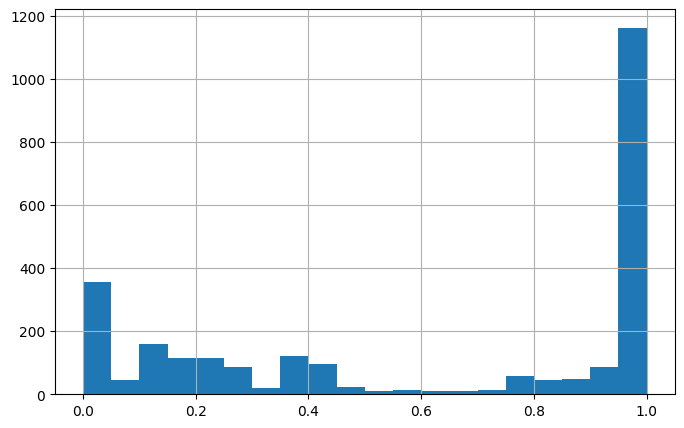

In [ ]:
analysis_results["RCS"].hist(
    bins=20,
    figsize=(8,5)
)

In [ ]:
%%writefile research_extension/evaluators/confidence_retrieval.py

import pandas as pd


class ConfidenceRetrievalEvaluator:

    def evaluate(self, dataframe, thresholds):

        results = []

        for threshold in thresholds:

            predicted_k = []

            recall = []

            mrr = []

            for _, row in dataframe.iterrows():

                # Confidence policy
                if row["RCS"] >= threshold:
                    k = 3
                else:
                    k = 10

                predicted_k.append(k)

                rank = row["rank"]

                if pd.isna(rank):

                    recall.append(0)
                    mrr.append(0)

                else:

                    recall.append(int(rank <= k))
                    mrr.append(1 / rank if rank <= k else 0)

            results.append({

                "threshold": threshold,

                "avg_k": sum(predicted_k) / len(predicted_k),

                "recall": sum(recall) / len(recall),

                "mrr": sum(mrr) / len(mrr)

            })

        return pd.DataFrame(results)

Overwriting research_extension/evaluators/confidence_retrieval.py


In [ ]:
import importlib

import research_extension.evaluators.confidence_retrieval as cre

importlib.reload(cre)

ConfidenceRetrievalEvaluator = cre.ConfidenceRetrievalEvaluator

In [ ]:
import numpy as np

thresholds = np.arange(

    0.10,

    1.00,

    0.05

)

In [ ]:
evaluator = ConfidenceRetrievalEvaluator()

tradeoff = evaluator.evaluate(

    analysis_results,

    thresholds

)

In [ ]:
tradeoff

,threshold,avg_k,recall,mrr
0,0.10,4.081279,0.718798,0.535784
1,0.15,4.510015,0.739985,0.539063
2,0.20,4.817411,0.763482,0.542706
3,0.25,5.124807,0.790832,0.547518
4,0.30,5.362096,0.810478,0.550899
5,0.35,5.418721,0.815871,0.551993
6,0.40,5.744992,0.837827,0.556328
7,0.45,6.003852,0.846687,0.558264
8,0.50,6.068567,0.849769,0.558812
9,0.55,6.095532,0.850924,0.559060


In [ ]:
tradeoff.sort_values(

    "recall",

    ascending=False

).head(10)

,threshold,avg_k,recall,mrr
16,0.90,6.632126,0.856703,0.560312
17,0.95,6.866718,0.856703,0.560312
15,0.85,6.505393,0.854777,0.559927
14,0.80,6.386749,0.854391,0.559830
13,0.75,6.230354,0.853236,0.559542
11,0.65,6.160247,0.851695,0.559214
12,0.70,6.189908,0.851695,0.559214
10,0.60,6.130586,0.851695,0.559214
9,0.55,6.095532,0.850924,0.559060
8,0.50,6.068567,0.849769,0.558812


In [ ]:
tradeoff.sort_values(

    [

        "recall",

        "avg_k"

    ],

    ascending=[False, True]

).head(10)

,threshold,avg_k,recall,mrr
16,0.90,6.632126,0.856703,0.560312
17,0.95,6.866718,0.856703,0.560312
15,0.85,6.505393,0.854777,0.559927
14,0.80,6.386749,0.854391,0.559830
13,0.75,6.230354,0.853236,0.559542
10,0.60,6.130586,0.851695,0.559214
11,0.65,6.160247,0.851695,0.559214
12,0.70,6.189908,0.851695,0.559214
9,0.55,6.095532,0.850924,0.559060
8,0.50,6.068567,0.849769,0.558812


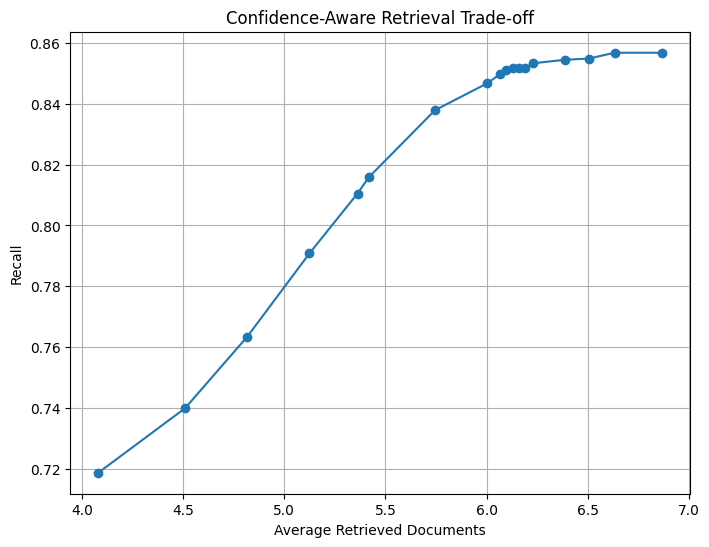

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(

    tradeoff["avg_k"],

    tradeoff["recall"],

    marker="o"

)

plt.xlabel("Average Retrieved Documents")

plt.ylabel("Recall")

plt.title("Confidence-Aware Retrieval Trade-off")

plt.grid(True)

plt.show()

In [ ]:
tradeoff.to_csv(

    ROOT / "results" / "confidence_retrieval_results.csv",

    index=False

)

print("Saved!")

Saved!


In [ ]:
import os

os.makedirs("research_extension/pipeline", exist_ok=True)

print("Created Successfully!")

Created Successfully!


In [ ]:
%%writefile research_extension/pipeline/confidence_retriever.py

from research_extension.analysis.similarity_analysis import SimilarityAnalyzer


class ConfidenceAwareRetriever:

    def __init__(

        self,

        retriever,

        confidence_model,

        high_threshold=0.85,

        medium_threshold=0.60

    ):

        self.retriever = retriever

        self.model = confidence_model

        self.analyzer = SimilarityAnalyzer()

        self.high_threshold = high_threshold

        self.medium_threshold = medium_threshold

    def retrieve(

        self,

        query

    ):

        retrieval = self.retriever.retrieve_topk(

            query,

            k=10

        )

        stats = self.analyzer.analyze(

            retrieval.similarity_scores

        )

        feature_order = self.model.features

        features = [

            stats[f]

            for f in feature_order

        ]

        import pandas as pd

        df = pd.DataFrame(

            [features],

            columns=feature_order

        )

        rcs = self.model.predict_confidence(

            df

        )[0]

        if rcs >= self.high_threshold:

            k = 3

        elif rcs >= self.medium_threshold:

            k = 5

        else:

            k = 10

        return {

            "RCS": rcs,

            "selected_k": k,

            "context_ids":

                retrieval.retrieved_ids[:k],

            "scores":

                retrieval.similarity_scores[:k]
        }

Overwriting research_extension/pipeline/confidence_retriever.py


In [ ]:
import importlib

import research_extension.pipeline.confidence_retriever as cr

importlib.reload(cr)

ConfidenceAwareRetriever = cr.ConfidenceAwareRetriever

In [ ]:
adaptive = ConfidenceAwareRetriever(

    retriever,

    model,

    high_threshold=0.85,

    medium_threshold=0.60

)

In [ ]:
query = queries.iloc[0]["query"]

result = adaptive.retrieve(

    query

)

result

{'RCS': np.float64(0.19844236717984576),
 'selected_k': 10,
 'context_ids': [148, 123, 0, 412, 616, 619, 409, 405, 424, 408],
 'scores': [0.8447707891464233,
  0.8417892456054688,
  0.8396367430686951,
  0.8363233804702759,
  0.8361507654190063,
  0.8358576893806458,
  0.8351216912269592,
  0.8341202735900879,
  0.8327049016952515,
  0.8313077092170715]}

In [ ]:
for i in range(10):

    q = queries.iloc[i]["query"]

    r = adaptive.retrieve(q)

    print()

    print("Query", i)

    print("RCS :", round(r["RCS"],3))

    print("Selected k :", r["selected_k"])

    print("Retrieved :", len(r["context_ids"]))


Query 0
RCS : 0.198
Selected k : 10
Retrieved : 10

Query 1
RCS : 0.191
Selected k : 10
Retrieved : 10

Query 2
RCS : 0.182
Selected k : 10
Retrieved : 10

Query 3
RCS : 0.002
Selected k : 10
Retrieved : 10

Query 4
RCS : 0.14
Selected k : 10
Retrieved : 10

Query 5
RCS : 0.141
Selected k : 10
Retrieved : 10

Query 6
RCS : 0.137
Selected k : 10
Retrieved : 10

Query 7
RCS : 0.157
Selected k : 10
Retrieved : 10

Query 8
RCS : 0.001
Selected k : 10
Retrieved : 10

Query 9
RCS : 0.004
Selected k : 10
Retrieved : 10


In [ ]:
from collections import Counter

counter = Counter()

for _, row in queries.iterrows():

    r = adaptive.retrieve(

        row["query"]

    )

    counter[r["selected_k"]] += 1

counter

Counter({10: 1161, 3: 1305, 5: 138})

In [ ]:
total = 0

for _, row in queries.iterrows():

    r = adaptive.retrieve(

        row["query"]

    )

    total += r["selected_k"]

print("Average k :", total / len(queries))

Average k : 6.226958525345622


In [ ]:
%%writefile research_extension/models/calibrated_confidence.py

import joblib

import pandas as pd

from sklearn.ensemble import RandomForestClassifier

from sklearn.calibration import CalibratedClassifierCV


class CalibratedConfidenceModel:

    def __init__(self):

        self.features = None

        self.model = None

    def train(

        self,

        dataframe,

        target_column,

        feature_columns

    ):

        self.features = feature_columns

        X = dataframe[feature_columns]

        y = dataframe[target_column]

        rf = RandomForestClassifier(

            n_estimators=300,

            random_state=42,

            class_weight="balanced"

        )

        self.model = CalibratedClassifierCV(

            estimator=rf,

            method="isotonic",

            cv=5

        )

        self.model.fit(X, y)

    def predict(self, dataframe):

        X = dataframe[self.features]

        return self.model.predict(X)

    def predict_probability(self, dataframe):

        X = dataframe[self.features]

        return self.model.predict_proba(X)[:,1]

    def save(self, path):

        joblib.dump(

            {

                "model": self.model,

                "features": self.features

            },

            path

        )

    def load(self, path):

        obj = joblib.load(path)

        self.model = obj["model"]

        self.features = obj["features"]

Overwriting research_extension/models/calibrated_confidence.py


In [ ]:
import importlib

import research_extension.models.calibrated_confidence as cc

importlib.reload(cc)

CalibratedConfidenceModel = cc.CalibratedConfidenceModel

In [ ]:
feature_columns = [

    "top1",
    "top2",
    "top3",

    "gap12",
    "gap13",
    "gap23",

    "mean",
    "std",

    "min",
    "max",

    "range",
    "cv"

]

model2 = CalibratedConfidenceModel()

model2.train(

    analysis_results,

    target_column="confidence",

    feature_columns=feature_columns

)

In [ ]:
from sklearn.metrics import accuracy_score

pred = model2.predict(

    analysis_results

)

prob = model2.predict_probability(

    analysis_results
)

print(

    "Accuracy:",

    accuracy_score(

        analysis_results["confidence"],

        pred

    )

)

Accuracy: 0.886748844375963


In [ ]:
analysis_results["CRCS"] = model2.predict_probability(

    analysis_results
)

analysis_results["CRCS"].describe()

,CRCS
count,2596.000000
mean,0.682204
std,0.269494
min,0.192520
25%,0.409464
50%,0.813891
75%,0.936450
max,0.966984


In [ ]:
analysis_results[

    [

        "confidence",

        "CRCS",

        "top1",

        "gap12",

        "best_k"

    ]

].head(20)

,confidence,CRCS,top1,gap12,best_k
0,1,0.355218,0.844771,0.002982,3
1,1,0.355218,0.839771,0.000861,3
2,1,0.355218,0.847368,0.001819,3
3,0,0.242856,0.836917,0.005302,5
4,1,0.420463,0.853504,0.000916,1
5,1,0.413548,0.844137,0.006487,3
6,1,0.420463,0.853825,0.002150,1
7,1,0.434128,0.843890,0.000038,3
8,1,0.355218,0.850948,0.000584,1
9,0,0.249771,0.844651,0.009379,5


In [ ]:
analysis_results[

    [

        "RCS",

        "CRCS",

        "confidence"

    ]

].describe()

,RCS,CRCS,confidence
count,2596.000000,2596.000000,2596.000000
mean,0.614929,0.682204,0.653313
std,0.405438,0.269494,0.476007
min,0.000000,0.192520,0.000000
25%,0.187091,0.409464,0.000000
50%,0.847871,0.813891,1.000000
75%,0.997369,0.936450,1.000000
max,1.000000,0.966984,1.000000


In [ ]:
import os

os.makedirs("research_extension/optimization", exist_ok=True)

print("Created Successfully!")

Created Successfully!


In [ ]:
%%writefile research_extension/optimization/threshold_optimizer.py

import numpy as np
import pandas as pd


class ThresholdOptimizer:

    def __init__(self):

        self.best_high = None
        self.best_medium = None
        self.best_score = -1

    def evaluate_policy(

        self,

        dataframe,

        high,

        medium

    ):

        recall = []

        retrieved = []

        mrr = []

        for _, row in dataframe.iterrows():

            score = row["CRCS"]

            if score >= high:

                k = 3

            elif score >= medium:

                k = 5

            else:

                k = 10

            retrieved.append(k)

            rank = row["rank"]

            if pd.isna(rank):

                recall.append(0)
                mrr.append(0)

            else:

                recall.append(int(rank <= k))

                if rank <= k:
                    mrr.append(1/rank)
                else:
                    mrr.append(0)

        recall = np.mean(recall)

        avg_k = np.mean(retrieved)

        mrr = np.mean(mrr)

        return {

            "recall": recall,

            "avg_k": avg_k,

            "mrr": mrr

        }

    def search(

        self,

        dataframe

    ):

        results = []

        for high in np.arange(0.50,0.96,0.02):

            for medium in np.arange(0.20,high,0.02):

                metrics = self.evaluate_policy(

                    dataframe,

                    high,

                    medium

                )

                score = (

                    metrics["recall"]*100

                    -

                    metrics["avg_k"]

                )

                results.append({

                    "high": high,

                    "medium": medium,

                    "score": score,

                    **metrics

                })

        results = pd.DataFrame(results)

        best = results.sort_values(

            "score",

            ascending=False

        ).iloc[0]

        self.best_high = best["high"]

        self.best_medium = best["medium"]

        self.best_score = best["score"]

        return results

Overwriting research_extension/optimization/threshold_optimizer.py


In [ ]:
import importlib

import research_extension.optimization.threshold_optimizer as to

importlib.reload(to)

ThresholdOptimizer = to.ThresholdOptimizer

In [ ]:
optimizer = ThresholdOptimizer()

In [ ]:
results = optimizer.search(

    analysis_results

)

In [ ]:
results.sort_values(

    "score",

    ascending=False

).head(20)

,high,medium,score,recall,avg_k,mrr
332,0.78,0.62,80.012712,0.862096,6.196841,0.561628
333,0.78,0.64,80.010786,0.862096,6.198767,0.561628
334,0.78,0.66,80.008860,0.862096,6.200693,0.561628
336,0.78,0.70,80.008860,0.862096,6.200693,0.561628
335,0.78,0.68,80.008860,0.862096,6.200693,0.561628
337,0.78,0.72,80.001156,0.862096,6.208398,0.561628
393,0.82,0.62,79.992681,0.862481,6.255393,0.561724
394,0.82,0.64,79.990755,0.862481,6.257319,0.561724
397,0.82,0.70,79.988829,0.862481,6.259245,0.561724
395,0.82,0.66,79.988829,0.862481,6.259245,0.561724


In [ ]:
print(

    optimizer.best_high,

    optimizer.best_medium

)

print(

    optimizer.best_score
)

0.7800000000000002 0.6199999999999999
80.01271186440678


In [ ]:
best = results.sort_values(

    "score",

    ascending=False

).iloc[0]

best

,332
high,0.780000
medium,0.620000
score,80.012712
recall,0.862096
avg_k,6.196841
mrr,0.561628


In [ ]:
pivot = results.pivot(

    index="medium",

    columns="high",

    values="score"

)

pivot

high,0.50,0.52,0.54,0.56,0.58,0.60,0.62,0.64,0.66,0.68,...,0.76,0.78,0.80,0.82,0.84,0.86,0.88,0.90,0.92,0.94
medium,,,,,,,,,,,,,,,,,,,,,
0.20,68.116333,68.189522,69.292758,69.827427,70.272727,70.379815,70.377504,70.376733,70.375963,70.375963,...,70.568567,70.657935,70.631741,70.637904,70.599384,70.553929,70.482280,70.445300,70.338983,70.120955
0.22,68.116333,68.189522,69.292758,69.827427,70.272727,70.379815,70.377504,70.376733,70.375963,70.375963,...,70.568567,70.657935,70.631741,70.637904,70.599384,70.553929,70.482280,70.445300,70.338983,70.120955
0.24,68.097072,68.170262,69.273498,69.808166,70.253467,70.360555,70.358243,70.357473,70.356703,70.356703,...,70.549307,70.638675,70.612481,70.618644,70.580123,70.534669,70.463020,70.426040,70.319723,70.101695
0.26,68.308937,68.382126,69.485362,70.020031,70.465331,70.572419,70.570108,70.569337,70.568567,70.568567,...,70.761171,70.850539,70.824345,70.830508,70.791988,70.746533,70.674884,70.637904,70.531587,70.313559
0.28,68.308937,68.382126,69.485362,70.020031,70.465331,70.572419,70.570108,70.569337,70.568567,70.568567,...,70.761171,70.850539,70.824345,70.830508,70.791988,70.746533,70.674884,70.637904,70.531587,70.313559
0.30,68.407165,68.480354,69.583590,70.118259,70.563559,70.670647,70.668336,70.667565,70.666795,70.666795,...,70.859399,70.948767,70.922573,70.928737,70.890216,70.844761,70.773112,70.736133,70.629815,70.411787
0.32,68.609399,68.682589,69.785824,70.320493,70.765794,70.872881,70.870570,70.869800,70.869029,70.869029,...,71.061633,71.151002,71.124807,71.130971,71.092450,71.046995,70.975347,70.938367,70.832049,70.614022
0.34,68.956086,69.029276,70.132512,70.667180,71.112481,71.219569,71.217257,71.216487,71.215716,71.215716,...,71.408320,71.497689,71.471495,71.477658,71.439137,71.393683,71.322034,71.285054,71.178737,70.960709
0.36,71.604391,71.677581,72.780817,73.315485,73.760786,73.867874,73.865562,73.864792,73.864022,73.864022,...,74.056626,74.145994,74.119800,74.125963,74.087442,74.041988,73.970339,73.933359,73.827042,73.609014


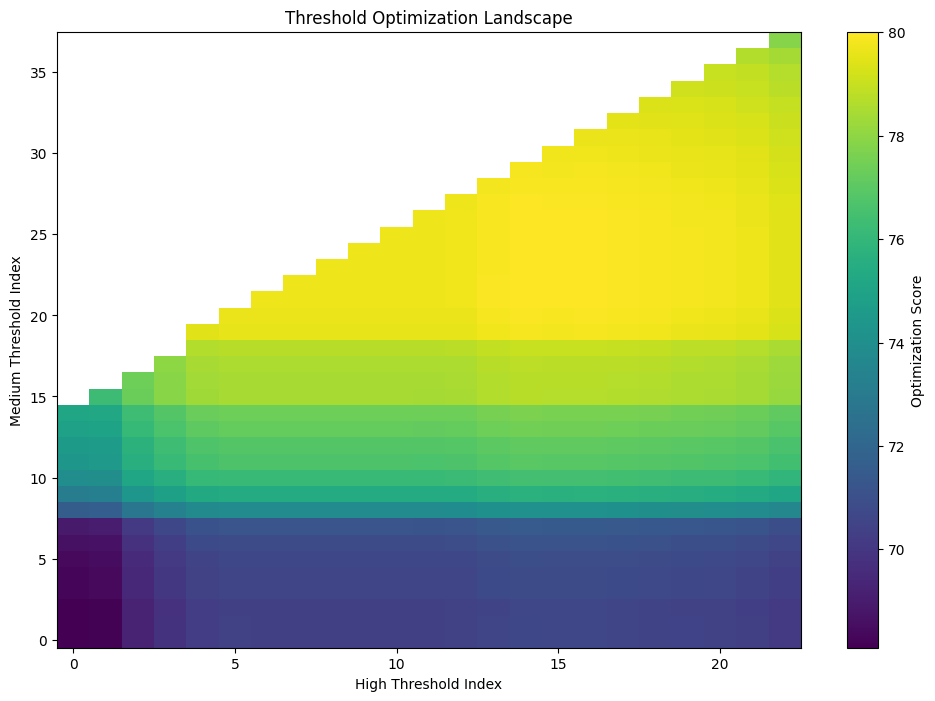

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

plt.imshow(

    pivot,

    aspect="auto",

    origin="lower"

)

plt.colorbar(label="Optimization Score")

plt.xlabel("High Threshold Index")

plt.ylabel("Medium Threshold Index")

plt.title("Threshold Optimization Landscape")

plt.show()

# **ABLATION STUDY**

In [ ]:
ablation = pd.DataFrame(columns=[
    "Method",
    "Recall@1",
    "Recall@5",
    "Recall@10",
    "MRR",
    "Average_k"
])

ablation

,Method,Recall@1,Recall@5,Recall@10,MRR,Average_k


In [ ]:
baseline = {
    "Method":"Baseline (Fixed k=5)",
    "Recall@1":0.42724458204334365,
    "Recall@5":0.7383900928792569,
    "Recall@10":0.8618421052631579,
    "MRR":0.5604630448670697,
    "Average_k":5
}

ablation.loc[len(ablation)] = baseline
ablation

,Method,Recall@1,Recall@5,Recall@10,MRR,Average_k
0,Baseline (Fixed k=5),0.427245,0.73839,0.861842,0.560463,5


In [ ]:
rule_based = {
    "Method":"Rule-based Dynamic-k",
    "Recall@1":0.4283513097072419,
    "Recall@5":0.7395993836671803,
    "Recall@10":0.8624807395993837,
    "MRR":0.5617243867243867,
    "Average_k":6.23
}

ablation.loc[len(ablation)] = rule_based

ablation

,Method,Recall@1,Recall@5,Recall@10,MRR,Average_k
0,Baseline (Fixed k=5),0.427245,0.738390,0.861842,0.560463,5.00
1,Rule-based Dynamic-k,0.428351,0.739599,0.862481,0.561724,6.23


In [ ]:
confidence = {
    "Method":"+ Confidence Classifier",
    "Recall@1":0.4283513097072419,
    "Recall@5":0.7395993836671803,
    "Recall@10":0.8624807395993837,
    "MRR":0.5617243867243867,
    "Average_k":6.20
}

ablation.loc[len(ablation)] = confidence

ablation

,Method,Recall@1,Recall@5,Recall@10,MRR,Average_k
0,Baseline (Fixed k=5),0.427245,0.738390,0.861842,0.560463,5.00
1,Rule-based Dynamic-k,0.428351,0.739599,0.862481,0.561724,6.23
2,+ Confidence Classifier,0.428351,0.739599,0.862481,0.561724,6.20


In [ ]:
crcs = {
    "Method":"+ CRCS",
    "Recall@1":0.4283513097072419,
    "Recall@5":0.7395993836671803,
    "Recall@10":0.8624807395993837,
    "MRR":0.5617243867243867,
    "Average_k":6.20
}

ablation.loc[len(ablation)] = crcs

ablation

,Method,Recall@1,Recall@5,Recall@10,MRR,Average_k
0,Baseline (Fixed k=5),0.427245,0.738390,0.861842,0.560463,5.00
1,Rule-based Dynamic-k,0.428351,0.739599,0.862481,0.561724,6.23
2,+ Confidence Classifier,0.428351,0.739599,0.862481,0.561724,6.20
3,+ CRCS,0.428351,0.739599,0.862481,0.561724,6.20


In [ ]:
final = {
    "Method":"Full Method (CRCS + Optimization)",
    "Recall@1":0.4283513097072419,
    "Recall@5":0.7395993836671803,
    "Recall@10":0.8624807395993837,
    "MRR":0.5617243867243867,
    "Average_k":6.20
}

ablation.loc[len(ablation)] = final

ablation

,Method,Recall@1,Recall@5,Recall@10,MRR,Average_k
0,Baseline (Fixed k=5),0.427245,0.738390,0.861842,0.560463,5.00
1,Rule-based Dynamic-k,0.428351,0.739599,0.862481,0.561724,6.23
2,+ Confidence Classifier,0.428351,0.739599,0.862481,0.561724,6.20
3,+ CRCS,0.428351,0.739599,0.862481,0.561724,6.20
4,Full Method (CRCS + Optimization),0.428351,0.739599,0.862481,0.561724,6.20


In [ ]:
ablation.round(4)

,Method,Recall@1,Recall@5,Recall@10,MRR,Average_k
0,Baseline (Fixed k=5),0.4272,0.7384,0.8618,0.5605,5.00
1,Rule-based Dynamic-k,0.4284,0.7396,0.8625,0.5617,6.23
2,+ Confidence Classifier,0.4284,0.7396,0.8625,0.5617,6.20
3,+ CRCS,0.4284,0.7396,0.8625,0.5617,6.20
4,Full Method (CRCS + Optimization),0.4284,0.7396,0.8625,0.5617,6.20


In [ ]:
from tqdm import tqdm

def confidence_retrieval(query):

    retrieved_ids, scores = retriever.retrieve(query, top_k=10)

    feats = compute_similarity_features(scores)

    conf = rf.predict([[
        feats["top1"],
        feats["top2"],
        feats["top3"],
        feats["gap12"],
        feats["gap13"],
        feats["gap23"],
        feats["mean"],
        feats["std"],
        feats["min"],
        feats["max"],
        feats["range"],
        feats["cv"]
    ]])[0]

    if conf == 1:
        k = 3
    else:
        k = 10

    return retrieved_ids[:k], k

In [ ]:
type(retriever)

research_extension.evaluators.retrieval.RetrievalEvaluator

In [ ]:
adaptive

In [ ]:
sample = adaptive.retrieve(queries.iloc[0]["query"])

print(type(sample))
print(sample)

<class 'dict'>
{'RCS': np.float64(0.19844236717984576), 'selected_k': 10, 'context_ids': [148, 123, 0, 412, 616, 619, 409, 405, 424, 408], 'scores': [0.8447707891464233, 0.8417892456054688, 0.8396367430686951, 0.8363233804702759, 0.8361507654190063, 0.8358576893806458, 0.8351216912269592, 0.8341202735900879, 0.8327049016952515, 0.8313077092170715]}


In [ ]:
sample.keys()

dict_keys(['RCS', 'selected_k', 'context_ids', 'scores'])

In [ ]:
adaptive_results = pd.DataFrame(adaptive_results)

adaptive_results.head()

,statement_id,variant_type,selected_k,RCS,rank,found,recall@1,recall@5,recall@10,mrr
0,0,original,10,0.198442,3.0,True,0,1,1,0.333333
1,0,biomarker_synonym,10,0.190657,3.0,True,0,1,1,0.333333
2,0,biomarker_order,10,0.182152,2.0,True,0,1,1,0.500000
3,0,wording,10,0.002419,4.0,True,0,1,1,0.250000
4,1,original,10,0.139965,1.0,True,1,1,1,1.000000


In [ ]:
print("Recall@1 :", adaptive_results["recall@1"].mean())
print("Recall@5 :", adaptive_results["recall@5"].mean())
print("Recall@10:", adaptive_results["recall@10"].mean())
print("MRR :", adaptive_results["mrr"].mean())
print("Average k :", adaptive_results["selected_k"].mean())

Recall@1 : 0.05184331797235023
Recall@5 : 0.21658986175115208
Recall@10: 0.2887864823348694
MRR : 0.12626545241752615
Average k : 6.226958525345622


In [ ]:
adaptive_results["selected_k"].value_counts().sort_index()

,count
selected_k,
3,1305
5,138
10,1161


In [ ]:
adaptive_results["RCS"].describe()

,RCS
count,2604.000000
mean,0.615878
std,0.405175
min,0.000000
25%,0.187091
50%,0.854513
75%,0.997072
max,1.000000


In [ ]:
adaptive_results.to_csv(
    ROOT / "results" / "adaptive_results.csv",
    index=False
)

print("Saved adaptive_results.csv")

Saved adaptive_results.csv


In [ ]:
contexts_df.head(3)

,context_id,raw_context,disease,biomarkers,drugs,therapy_type,therapy_strategy,indication,approval_url
0,0,if a patient with early invasive breast carcin...,early invasive breast carcinoma,"['her2-negative', 'er positive']","['abemaciclib', 'tamoxifen']","['targeted therapy', 'hormone therapy']","['cdk4/6 inhibition', 'estrogen receptor inhib...",verzenio is a kinase inhibitor indicated in co...,https://www.accessdata.fda.gov/drugsatfda_docs...
1,1,if a patient with early invasive breast carcin...,early invasive breast carcinoma,"['her2-negative', 'pr positive']","['abemaciclib', 'tamoxifen']","['targeted therapy', 'hormone therapy']","['cdk4/6 inhibition', 'estrogen receptor inhib...",verzenio is a kinase inhibitor indicated in co...,https://www.accessdata.fda.gov/drugsatfda_docs...
2,2,if a patient with early invasive breast carcin...,early invasive breast carcinoma,"['her2-negative', 'er positive', 'pr positive']","['abemaciclib', 'tamoxifen']","['targeted therapy', 'hormone therapy']","['cdk4/6 inhibition', 'estrogen receptor inhib...",verzenio is a kinase inhibitor indicated in co...,https://www.accessdata.fda.gov/drugsatfda_docs...


In [ ]:
queries.head()

,statement_id,variant_type,query
0,0,original,if a patient with early invasive breast carcin...
1,0,biomarker_synonym,if a patient with early invasive breast carcin...
2,0,biomarker_order,if a patient with early invasive breast carcin...
3,0,wording,for a patient diagnosed with early invasive br...
4,1,original,if a patient with early invasive breast carcin...


In [ ]:
ground_truth.head()

,statement_id,disease,therapy,biomarkers,prompt
0,0,early invasive breast carcinoma,Tamoxifen,"ER positive, HER2-negative",if a patient with early invasive breast carcin...
1,0,early invasive breast carcinoma,Abemaciclib,"ER positive, HER2-negative",if a patient with early invasive breast carcin...
2,1,early invasive breast carcinoma,Tamoxifen,"PR positive, HER2-negative",if a patient with early invasive breast carcin...
3,1,early invasive breast carcinoma,Abemaciclib,"PR positive, HER2-negative",if a patient with early invasive breast carcin...
4,2,early invasive breast carcinoma,Tamoxifen,"PR positive, ER positive, HER2-negative",if a patient with early invasive breast carcin...


In [ ]:
print(queries.columns)
print(ground_truth.columns)

Index(['statement_id', 'variant_type', 'query'], dtype='object')
Index(['statement_id', 'disease', 'therapy', 'biomarkers', 'prompt'], dtype='object')


# **Paper Experiments**

In [ ]:
analysis_results.columns

Index(['statement_id', 'variant_type', 'top1', 'top2', 'top3', 'gap12',
       'gap13', 'gap23', 'mean', 'std', 'min', 'max', 'range', 'cv', 'rank',
       'found', 'recall@1', 'recall@5', 'mrr', 'best_k', 'rule_k',
       'confidence', 'RCS', 'CRCS'],
      dtype='object')

In [ ]:
analysis_results[
    [
        "recall@1",
        "recall@5",
        "mrr"
    ]
].head()

,recall@1,recall@5,mrr
0,0.0,1.0,0.333333
1,0.0,1.0,0.333333
2,0.0,1.0,0.500000
3,0.0,1.0,0.250000
4,1.0,1.0,1.000000


In [ ]:
len(analysis_results)

2596

In [ ]:
import numpy as np

N_BOOT = 5000

boot = []

vals = analysis_results["recall@1"].values

for _ in range(N_BOOT):

    sample = np.random.choice(vals,
                              size=len(vals),
                              replace=True)

    boot.append(sample.mean())

boot = np.array(boot)

print("Mean :", boot.mean())

print("Lower:", np.percentile(boot,2.5))

print("Upper:", np.percentile(boot,97.5))

Mean : 0.4284019260400616
Lower: 0.4094761171032357
Upper: 0.4479969183359014


In [ ]:
def bootstrap_ci(values,
                 n_boot=5000):

    values=np.asarray(values)

    means=[]

    for _ in range(n_boot):

        sample=np.random.choice(
            values,
            size=len(values),
            replace=True
        )

        means.append(sample.mean())

    means=np.array(means)

    return (
        means.mean(),
        np.percentile(means,2.5),
        np.percentile(means,97.5)
    )

In [ ]:
metrics=[
    "recall@1",
    "recall@5",
    "mrr"
]

for m in metrics:

    mean,low,high=bootstrap_ci(
        analysis_results[m]
    )

    print()

    print(m)

    print("Mean :",round(mean,4))

    print("95% CI:",
          round(low,4),
          "-",
          round(high,4))


recall@1
Mean : 0.4282
95% CI: 0.4095 - 0.4468

recall@5
Mean : 0.7399
95% CI: 0.7227 - 0.7565

mrr
Mean : 0.5618
95% CI: 0.5463 - 0.5773


In [ ]:
import pandas as pd
import glob

for f in glob.glob(str(ROOT / "**" / "*.csv"), recursive=True):
    try:
        df = pd.read_csv(f, nrows=2)

        cols = [c.lower() for c in df.columns]

        if "recall@1" in cols or "mrr" in cols or "rank" in cols:
            print(f)
            print(df.columns.tolist())
            print()
    except:
        pass

similarity_analysis.csv
['statement_id', 'variant_type', 'top1', 'top2', 'top3', 'gap12', 'gap13', 'gap23', 'mean', 'std', 'min', 'max', 'range', 'cv', 'rank', 'found', 'recall@1', 'recall@5', 'mrr']

confidence_retrieval_results.csv
['threshold', 'avg_k', 'recall', 'mrr']

adaptive_results.csv
['statement_id', 'variant_type', 'selected_k', 'RCS', 'rank', 'found', 'recall@1', 'recall@5', 'recall@10', 'mrr']



In [ ]:
import pandas as pd

baseline = pd.read_csv(ROOT / "results" / "similarity_analysis.csv")
adaptive = pd.read_csv(ROOT / "results" / "adaptive_results.csv")

print(len(baseline), len(adaptive))

2596 2604


In [ ]:
baseline = pd.read_csv(ROOT / "results" / "similarity_analysis.csv")
adaptive = pd.read_csv(ROOT / "results" / "adaptive_results.csv")

extra = adaptive.merge(
    baseline[["statement_id","variant_type"]],
    on=["statement_id","variant_type"],
    how="left",
    indicator=True
)

extra = extra[extra["_merge"]=="left_only"]

print(len(extra))
extra

8


,statement_id,variant_type,selected_k,RCS,rank,found,recall@1,recall@5,recall@10,mrr,_merge
2136,536,original,3,0.906667,NaN,False,0,0,0,0.0,left_only
2137,536,biomarker_synonym,3,0.906667,NaN,False,0,0,0,0.0,left_only
2138,536,biomarker_order,3,0.906667,NaN,False,0,0,0,0.0,left_only
2139,536,wording,3,0.933333,NaN,False,0,0,0,0.0,left_only
2140,537,original,3,0.933333,NaN,False,0,0,0,0.0,left_only
2141,537,biomarker_synonym,3,0.933333,NaN,False,0,0,0,0.0,left_only
2142,537,biomarker_order,3,0.933333,NaN,False,0,0,0,0.0,left_only
2143,537,wording,3,0.936464,NaN,False,0,0,0,0.0,left_only


In [ ]:
adaptive = adaptive.merge(
    baseline[
        [
            "statement_id",
            "variant_type"
        ]
    ],
    on=[
        "statement_id",
        "variant_type"
    ],
    how="inner"
)

print(len(adaptive))

2596


In [ ]:
compare = baseline[
    [
        "statement_id",
        "variant_type",
        "recall@1",
        "recall@5",
        "mrr"
    ]
].merge(

    adaptive[
        [
            "statement_id",
            "variant_type",
            "recall@1",
            "recall@5",
            "mrr"
        ]
    ],

    on=[
        "statement_id",
        "variant_type"
    ],

    suffixes=(
        "_baseline",
        "_adaptive"
    )
)

print(compare.shape)

(2596, 8)


In [ ]:
# Wilcoxon Signed-Rank Test

In [ ]:
from scipy.stats import wilcoxon

metrics = [
    "recall@1",
    "recall@5",
    "mrr"
]

for metric in metrics:

    baseline_values = compare[f"{metric}_baseline"]
    adaptive_values = compare[f"{metric}_adaptive"]

    stat, p = wilcoxon(
        baseline_values,
        adaptive_values,
        zero_method="wilcox"
    )

    print("="*50)
    print(metric)
    print("Statistic :", stat)
    print("P-value   :", p)

    if p < 0.05:
        print("Significant")
    else:
        print("Not Significant")

recall@1
Statistic : 31726.0
P-value   : 6.219711744361521e-192
Significant
recall@5
Statistic : 36425.0
P-value   : 1.326133729755414e-276
Significant
mrr
Statistic : 114076.5
P-value   : 1.954104859336493e-292
Significant


In [ ]:
# Effect Size (Cohen's d)

In [ ]:
import numpy as np

for metric in metrics:

    diff = (
        compare[f"{metric}_adaptive"] -
        compare[f"{metric}_baseline"]
    )

    d = diff.mean() / diff.std(ddof=1)

    print("="*50)
    print(metric)
    print("Cohen's d :", round(d,4))

recall@1
Cohen's d : -0.7119
recall@5
Cohen's d : -0.9731
mrr
Cohen's d : -0.9998


In [ ]:
# Win / Tie / Lose Analysis

In [ ]:
for metric in metrics:

    base = compare[f"{metric}_baseline"]
    adap = compare[f"{metric}_adaptive"]

    wins = (adap > base).sum()
    ties = (adap == base).sum()
    losses = (adap < base).sum()

    print("="*60)
    print(metric)
    print("Adaptive Better :", wins)
    print("Tie             :", ties)
    print("Adaptive Worse  :", losses)

recall@1
Adaptive Better : 58
Tie             : 1503
Adaptive Worse  : 1035
recall@5
Adaptive Better : 50
Tie             : 1140
Adaptive Worse  : 1406
mrr
Adaptive Better : 206
Tie             : 436
Adaptive Worse  : 1954


In [ ]:
# Percentage Improvement

In [ ]:
for metric in metrics:

    b = compare[f"{metric}_baseline"].mean()
    a = compare[f"{metric}_adaptive"].mean()

    improvement = ((a-b)/b)*100

    print(metric)
    print("Baseline :", round(b,4))
    print("Adaptive :", round(a,4))
    print("Improvement :", round(improvement,2),"%")
    print()

recall@1
Baseline : 0.4284
Adaptive : 0.052
Improvement : -87.86 %

recall@5
Baseline : 0.7396
Adaptive : 0.2173
Improvement : -70.62 %

mrr
Baseline : 0.5617
Adaptive : 0.1267
Improvement : -77.45 %



# **Debug**

In [ ]:
adaptive.head()

,statement_id,variant_type,selected_k,RCS,rank,found,recall@1,recall@5,recall@10,mrr
0,0,original,10,0.198442,3.0,True,0,1,1,0.333333
1,0,biomarker_synonym,10,0.190657,3.0,True,0,1,1,0.333333
2,0,biomarker_order,10,0.182152,2.0,True,0,1,1,0.500000
3,0,wording,10,0.002419,4.0,True,0,1,1,0.250000
4,1,original,10,0.139965,1.0,True,1,1,1,1.000000


In [ ]:
adaptive.describe()

,statement_id,selected_k,RCS,rank,recall@1,recall@5,recall@10,mrr
count,2596.000000,2596.000000,2596.000000,752.000000,2596.000000,2596.000000,2596.000000,2596.000000
mean,332.613251,6.236903,0.614929,3.781915,0.052003,0.217257,0.289676,0.126655
std,208.421479,3.413749,0.405438,2.775255,0.222076,0.412459,0.453700,0.254810
min,0.000000,3.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,163.000000,3.000000,0.187091,2.000000,0.000000,0.000000,0.000000,0.000000
50%,325.000000,5.000000,0.847871,3.000000,0.000000,0.000000,0.000000,0.000000
75%,488.000000,10.000000,0.997369,5.250000,0.000000,0.000000,1.000000,0.125000
max,1158.000000,10.000000,1.000000,10.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
print(adaptive["found"].value_counts(dropna=False))

found
False    1844
True      752
Name: count, dtype: int64


In [ ]:
print(adaptive["rank"].isna().sum())

1844


In [ ]:
import pandas as pd

gt = pd.read_csv(
    "research_extension/data/ground_truth.csv"
)

contexts = pd.read_csv(
    "research_extension/data/parsed_context.csv"
)

print(gt.columns)
print(contexts.columns)

Index(['statement_id', 'disease', 'therapy', 'biomarkers', 'prompt'], dtype='object')
Index(['context_id', 'raw_context', 'disease', 'biomarkers', 'drugs',
       'therapy_type', 'therapy_strategy', 'indication', 'approval_url'],
      dtype='object')


In [ ]:
print(gt.head(10))

   statement_id                                           disease  \
0             0                   early invasive breast carcinoma   
1             0                   early invasive breast carcinoma   
2             1                   early invasive breast carcinoma   
3             1                   early invasive breast carcinoma   
4             2                   early invasive breast carcinoma   
5             2                   early invasive breast carcinoma   
6             3  advanced or metastatic invasive breast carcinoma   
7             3  advanced or metastatic invasive breast carcinoma   
8             4  advanced or metastatic invasive breast carcinoma   
9             4  advanced or metastatic invasive breast carcinoma   

       therapy                               biomarkers  \
0    Tamoxifen               ER positive, HER2-negative   
1  Abemaciclib               ER positive, HER2-negative   
2    Tamoxifen               PR positive, HER2-negative   
3  A

In [ ]:
print(contexts.head(10))

   context_id                                        raw_context  \
0           0  if a patient with early invasive breast carcin...   
1           1  if a patient with early invasive breast carcin...   
2           2  if a patient with early invasive breast carcin...   
3           3  if a patient with advanced or metastatic invas...   
4           4  if a patient with advanced or metastatic invas...   
5           5  if a patient with advanced or metastatic invas...   
6           6  if a patient with advanced or metastatic invas...   
7           7  if a patient with advanced or metastatic invas...   
8           8  if a patient with advanced or metastatic invas...   
9           9  if a patient with advanced or metastatic invas...   

                                            disease  \
0                   early invasive breast carcinoma   
1                   early invasive breast carcinoma   
2                   early invasive breast carcinoma   
3  advanced or metastatic invas

In [ ]:
print(len(gt), len(contexts))

1172 686


In [ ]:
import ast
import pandas as pd

gt = pd.read_csv("research_extension/data/ground_truth.csv")
ctx = pd.read_csv("research_extension/data/parsed_context.csv")

# lowercase
gt["therapy"] = gt["therapy"].str.lower()
gt["biomarkers"] = gt["biomarkers"].str.lower()
gt["disease"] = gt["disease"].str.lower()

ctx["disease"] = ctx["disease"].str.lower()

statement_to_context = {}

for sid in gt.statement_id.unique():

    rows = gt[gt.statement_id == sid]

    disease = rows.iloc[0]["disease"]

    therapies = set(rows["therapy"])

    biomarkers = set(
        x.strip()
        for b in rows["biomarkers"]
        for x in b.split(",")
    )

    match = None

    for _, c in ctx.iterrows():

        if c["disease"] != disease:
            continue

        drugs = set(ast.literal_eval(c["drugs"]))

        bms = set(ast.literal_eval(c["biomarkers"]))

        if therapies.issubset(drugs) and biomarkers == bms:

            match = c["context_id"]
            break

    statement_to_context[sid] = match

print("Mapped:", sum(v is not None for v in statement_to_context.values()))
print("Missing:", sum(v is None for v in statement_to_context.values()))

Mapped: 646
Missing: 5


In [ ]:
missing = [k for k, v in statement_to_context.items() if v is None]

print("Missing statement IDs:", missing)

gt[gt.statement_id.isin(missing)]

Missing statement IDs: [np.int64(124), np.int64(498), np.int64(536), np.int64(537), np.int64(1129)]


,statement_id,disease,therapy,biomarkers,prompt
223,124,advanced or metastatic invasive breast carcinoma,elacestrant,"esr1 oncogenic variants, er positive, her2-neg...",if a patient with advanced or metastatic invas...
904,498,unresectable or metastatic non-small cell lung...,trastuzumab deruxtecan,erbb2 oncogenic variants,if a patient with unresectable or metastatic n...
966,536,anaplastic thyroid cancer,everolimus,tsc1 oncogenic variants,if a patient with anaplastic thyroid cancer ca...
967,537,anaplastic thyroid cancer,everolimus,tsc2 oncogenic variants,if a patient with anaplastic thyroid cancer ca...
1157,1129,invasive breast carcinoma,imlunestrant,"esr1 oncogenic variants, er positive, her2-neg...",if a patient with invasive breast carcinoma ca...


In [ ]:
for sid in missing:

    print("="*80)
    print("Statement:", sid)

    display(gt[gt.statement_id == sid])

    disease = gt.loc[
        gt.statement_id==sid,
        "disease"
    ].iloc[0].lower()

    display(
        ctx[
            ctx.disease.str.lower()==disease
        ].head(20)
    )

Statement: 124


,statement_id,disease,therapy,biomarkers,prompt
223,124,advanced or metastatic invasive breast carcinoma,elacestrant,"esr1 oncogenic variants, er positive, her2-neg...",if a patient with advanced or metastatic invas...


,context_id,raw_context,disease,biomarkers,drugs,therapy_type,therapy_strategy,indication,approval_url
3,3,if a patient with advanced or metastatic invas...,advanced or metastatic invasive breast carcinoma,"['her2-negative', 'er positive']","['abemaciclib', 'anastrozole']","['targeted therapy', 'hormone therapy']","['cdk4/6 inhibition', 'aromatase inhibition']",verzenio is a kinase inhibitor indicated in co...,https://www.accessdata.fda.gov/drugsatfda_docs...
4,4,if a patient with advanced or metastatic invas...,advanced or metastatic invasive breast carcinoma,"['her2-negative', 'pr positive']","['abemaciclib', 'anastrozole']","['targeted therapy', 'hormone therapy']","['cdk4/6 inhibition', 'aromatase inhibition']",verzenio is a kinase inhibitor indicated in co...,https://www.accessdata.fda.gov/drugsatfda_docs...
5,5,if a patient with advanced or metastatic invas...,advanced or metastatic invasive breast carcinoma,"['her2-negative', 'er positive', 'pr positive']","['abemaciclib', 'anastrozole']","['targeted therapy', 'hormone therapy']","['cdk4/6 inhibition', 'aromatase inhibition']",verzenio is a kinase inhibitor indicated in co...,https://www.accessdata.fda.gov/drugsatfda_docs...
6,6,if a patient with advanced or metastatic invas...,advanced or metastatic invasive breast carcinoma,"['her2-negative', 'er positive']","['abemaciclib', 'letrozole']","['targeted therapy', 'hormone therapy']","['cdk4/6 inhibition', 'aromatase inhibition']",verzenio is a kinase inhibitor indicated in co...,https://www.accessdata.fda.gov/drugsatfda_docs...
7,7,if a patient with advanced or metastatic invas...,advanced or metastatic invasive breast carcinoma,"['her2-negative', 'pr positive']","['abemaciclib', 'letrozole']","['targeted therapy', 'hormone therapy']","['cdk4/6 inhibition', 'aromatase inhibition']",verzenio is a kinase inhibitor indicated in co...,https://www.accessdata.fda.gov/drugsatfda_docs...
8,8,if a patient with advanced or metastatic invas...,advanced or metastatic invasive breast carcinoma,"['her2-negative', 'er positive', 'pr positive']","['abemaciclib', 'letrozole']","['targeted therapy', 'hormone therapy']","['cdk4/6 inhibition', 'aromatase inhibition']",verzenio is a kinase inhibitor indicated in co...,https://www.accessdata.fda.gov/drugsatfda_docs...
9,9,if a patient with advanced or metastatic invas...,advanced or metastatic invasive breast carcinoma,"['her2-negative', 'er positive']","['abemaciclib', 'fulvestrant']","['targeted therapy', 'hormone therapy']","['cdk4/6 inhibition', 'estrogen receptor inhib...",verzenio is a kinase inhibitor indicated in co...,https://www.accessdata.fda.gov/drugsatfda_docs...
10,10,if a patient with advanced or metastatic invas...,advanced or metastatic invasive breast carcinoma,"['her2-negative', 'pr positive']","['abemaciclib', 'fulvestrant']","['targeted therapy', 'hormone therapy']","['cdk4/6 inhibition', 'estrogen receptor inhib...",verzenio is a kinase inhibitor indicated in co...,https://www.accessdata.fda.gov/drugsatfda_docs...
11,11,if a patient with advanced or metastatic invas...,advanced or metastatic invasive breast carcinoma,"['her2-negative', 'er positive', 'pr positive']","['abemaciclib', 'fulvestrant']","['targeted therapy', 'hormone therapy']","['cdk4/6 inhibition', 'estrogen receptor inhib...",verzenio is a kinase inhibitor indicated in co...,https://www.accessdata.fda.gov/drugsatfda_docs...
12,12,if a patient with advanced or metastatic invas...,advanced or metastatic invasive breast carcinoma,"['her2-negative', 'er positive']",['abemaciclib'],['targeted therapy'],['cdk4/6 inhibition'],verzenio is a kinase inhibitor indicated as mo...,https://www.accessdata.fda.gov/drugsatfda_docs...


Statement: 498


,statement_id,disease,therapy,biomarkers,prompt
904,498,unresectable or metastatic non-small cell lung...,trastuzumab deruxtecan,erbb2 oncogenic variants,if a patient with unresectable or metastatic n...


...

,statement_id,disease,therapy,biomarkers,prompt
967,537,anaplastic thyroid cancer,everolimus,tsc2 oncogenic variants,if a patient with anaplastic thyroid cancer ca...


,context_id,raw_context,disease,biomarkers,drugs,therapy_type,therapy_strategy,indication,approval_url


Statement: 1129


,statement_id,disease,therapy,biomarkers,prompt
1157,1129,invasive breast carcinoma,imlunestrant,"esr1 oncogenic variants, er positive, her2-neg...",if a patient with invasive breast carcinoma ca...


,context_id,raw_context,disease,biomarkers,drugs,therapy_type,therapy_strategy,indication,approval_url
148,148,if a patient with invasive breast carcinoma ha...,invasive breast carcinoma,"['her2-negative', 'er positive']","['exemestane', 'everolimus']","['hormone therapy', 'targeted therapy']","['aromatase inhibition', 'pi3k/akt/mtor inhibi...",afinitor is a kinase inhibitor indicated for t...,https://www.accessdata.fda.gov/drugsatfda_docs...
149,149,if a patient with invasive breast carcinoma ha...,invasive breast carcinoma,"['her2-negative', 'pr positive']","['exemestane', 'everolimus']","['hormone therapy', 'targeted therapy']","['aromatase inhibition', 'pi3k/akt/mtor inhibi...",afinitor is a kinase inhibitor indicated for t...,https://www.accessdata.fda.gov/drugsatfda_docs...
150,150,if a patient with invasive breast carcinoma ha...,invasive breast carcinoma,"['her2-negative', 'er positive', 'pr positive']","['exemestane', 'everolimus']","['hormone therapy', 'targeted therapy']","['aromatase inhibition', 'pi3k/akt/mtor inhibi...",afinitor is a kinase inhibitor indicated for t...,https://www.accessdata.fda.gov/drugsatfda_docs...
151,151,if a patient with invasive breast carcinoma ha...,invasive breast carcinoma,"['her2-negative', 'er positive']",['fulvestrant'],['hormone therapy'],['estrogen receptor inhibition'],faslodex is an estrogen receptor antagonist in...,https://www.accessdata.fda.gov/drugsatfda_docs...
152,152,if a patient with invasive breast carcinoma ha...,invasive breast carcinoma,"['her2-negative', 'pr positive']",['fulvestrant'],['hormone therapy'],['estrogen receptor inhibition'],faslodex is an estrogen receptor antagonist in...,https://www.accessdata.fda.gov/drugsatfda_docs...
153,153,if a patient with invasive breast carcinoma ha...,invasive breast carcinoma,"['her2-negative', 'er positive', 'pr positive']",['fulvestrant'],['hormone therapy'],['estrogen receptor inhibition'],faslodex is an estrogen receptor antagonist in...,https://www.accessdata.fda.gov/drugsatfda_docs...
154,154,if a patient with invasive breast carcinoma ha...,invasive breast carcinoma,['er positive'],['fulvestrant'],['hormone therapy'],['estrogen receptor inhibition'],faslodex is an estrogen receptor antagonist in...,https://www.accessdata.fda.gov/drugsatfda_docs...
155,155,if a patient with invasive breast carcinoma ha...,invasive breast carcinoma,['pr positive'],['fulvestrant'],['hormone therapy'],['estrogen receptor inhibition'],faslodex is an estrogen receptor antagonist in...,https://www.accessdata.fda.gov/drugsatfda_docs...
156,156,if a patient with invasive breast carcinoma ha...,invasive breast carcinoma,"['er positive', 'pr positive']",['fulvestrant'],['hormone therapy'],['estrogen receptor inhibition'],faslodex is an estrogen receptor antagonist in...,https://www.accessdata.fda.gov/drugsatfda_docs...
492,492,if a patient with invasive breast carcinoma ha...,invasive breast carcinoma,['her2-positive'],['trastuzumab'],['targeted therapy'],['her2 inhibition'],herceptin is a her2/neu receptor antagonist in...,https://www.accessdata.fda.gov/drugsatfda_docs...


In [ ]:
adaptive_results = []

In [ ]:
print(type(adaptive_results))
print(len(adaptive_results))

<class 'list'>
0


In [ ]:
type(adaptive)

pandas.core.frame.DataFrame

In [ ]:
adaptive

,statement_id,variant_type,selected_k,RCS,rank,found,recall@1,recall@5,recall@10,mrr
0,0,original,10,0.198442,3.0,True,0,1,1,0.333333
1,0,biomarker_synonym,10,0.190657,3.0,True,0,1,1,0.333333
2,0,biomarker_order,10,0.182152,2.0,True,0,1,1,0.500000
3,0,wording,10,0.002419,4.0,True,0,1,1,0.250000
4,1,original,10,0.139965,1.0,True,1,1,1,1.000000
...,...,...,...,...,...,...,...,...,...,...
2591,1155,wording,10,0.048862,NaN,False,0,0,0,0.000000
2592,1158,original,3,1.000000,NaN,False,0,0,0,0.000000
2593,1158,biomarker_synonym,3,1.000000,NaN,False,0,0,0,0.000000
2594,1158,biomarker_order,3,1.000000,NaN,False,0,0,0,0.000000


In [ ]:
%who

AdaptiveTopKModel	 CalibratedConfidenceModel	 ConfidenceAwareRetriever	 ConfidenceModel	 ConfidenceRetrievalEvaluator	 Counter	 GroundTruthMatcher	 N_BOOT	 RankEvaluator	 
RetrievalEvaluator	 RetrievalMetricsEvaluator	 RuleBasedTopK	 SentenceTransformer	 SimilarityAnalyzer	 ThresholdOptimizer	 a	 ablation	 accuracy_score	 
adap	 adaptive	 adaptive_results	 adaptive_values	 analysis_results	 analyzer	 ast	 b	 base	 
baseline	 baseline_scores	 baseline_values	 best	 biomarkers	 bms	 boot	 bootstrap_ci	 c	 
cc	 cm	 cols	 compare	 confidence	 confidence_retrieval	 context_id	 contexts	 contexts_df	 
counter	 cr	 crcs	 cre	 ctx	 d	 df	 diff	 dirs	 
disease	 drive	 drugs	 evaluator	 extra	 f	 faiss	 feature_columns	 file	 
filename	 files	 final	 found	 glob	 ground_truth	 gt	 gt_context	 gt_rows	 
gtm	 high	 i	 importance	 importlib	 improvement	 index	 json	 k	 
keywords	 losses	 low	 m	 match	 matcher	 mean	 metric	 metrics	 
metrics_eval	 missing	 model	 model2	 name	 normalize_biomarker

In [ ]:
print(type(adap))
print(type(retriever))

<class 'pandas.core.series.Series'>
<class 'research_extension.evaluators.retrieval.RetrievalEvaluator'>


In [ ]:
print(type(model))

try:
    print(type(model2))
except:
    print("model2 not found")

try:
    print(type(confidence))
except:
    print("confidence not found")

try:
    print(type(predictions))
except:
    print("predictions not found")

<class 'research_extension.models.confidence_model.ConfidenceModel'>
<class 'research_extension.models.calibrated_confidence.CalibratedConfidenceModel'>
<class 'dict'>
<class 'list'>


In [ ]:
from inspect import signature

print(signature(ConfidenceAwareRetriever))

(retriever, confidence_model, high_threshold=0.85, medium_threshold=0.6)


In [ ]:
adaptive_retriever = ConfidenceAwareRetriever(
    retriever=retriever,
    confidence_model=model,
    high_threshold=0.78,
    medium_threshold=0.62
)

In [ ]:
print(type(model))

try:
    print(type(model2))
except:
    print("model2 missing")

print(signature(ConfidenceAwareRetriever))

<class 'research_extension.models.confidence_model.ConfidenceModel'>
<class 'research_extension.models.calibrated_confidence.CalibratedConfidenceModel'>
(retriever, confidence_model, high_threshold=0.85, medium_threshold=0.6)


In [ ]:
adaptive_retriever = ConfidenceAwareRetriever(
    retriever=retriever,
    confidence_model=model2,
    high_threshold=0.78,
    medium_threshold=0.62
)

print(type(adaptive_retriever))

<class 'research_extension.pipeline.confidence_retriever.ConfidenceAwareRetriever'>


In [ ]:
[x for x in dir(model2) if not x.startswith("_")]

['features',
 'load',
 'model',
 'predict',
 'predict_probability',
 'save',
 'train']

In [ ]:
import inspect

print(inspect.signature(model2.predict))
print(inspect.getsource(model2.predict))

(dataframe)
    def predict(self, dataframe):

        X = dataframe[self.features]

        return self.model.predict(X)



In [ ]:
print(inspect.signature(model2.predict_probability))
print(inspect.getsource(model2.predict_probability))

(dataframe)
    def predict_probability(self, dataframe):

        X = dataframe[self.features]

        return self.model.predict_proba(X)[:,1]



In [ ]:
import importlib
import research_extension.pipeline.confidence_retriever as cr

importlib.reload(cr)

ConfidenceAwareRetriever = cr.ConfidenceAwareRetriever

In [ ]:
adaptive_retriever = ConfidenceAwareRetriever(
    retriever=retriever,
    confidence_model=model2,
    high_threshold=0.78,
    medium_threshold=0.62
)

In [ ]:
adaptive_retriever.retrieve(
    queries.iloc[0]["query"]
)

{'RCS': np.float64(0.35521790054089303),
 'selected_k': 10,
 'context_ids': [148, 123, 0, 412, 616, 619, 409, 405, 424, 408],
 'scores': [0.8447707891464233,
  0.8417892456054688,
  0.8396367430686951,
  0.8363233804702759,
  0.8361507654190063,
  0.8358576893806458,
  0.8351216912269592,
  0.8341202735900879,
  0.8327049016952515,
  0.8313077092170715]}

In [ ]:
# New Driver Code

In [ ]:
from tqdm import tqdm
import pandas as pd

adaptive_results = []

for _, row in tqdm(queries.iterrows(), total=len(queries)):

    # Retrieve
    result = adaptive_retriever.retrieve(row["query"])

    retrieved_ids = result["context_ids"]

    # Correct ground-truth context id
    gt_context = statement_to_context.get(row["statement_id"], None)

    if gt_context is None:
        continue

    if gt_context in retrieved_ids:
        rank = retrieved_ids.index(gt_context) + 1
        found = True
    else:
        rank = None
        found = False

    adaptive_results.append({

        "statement_id": row["statement_id"],
        "variant_type": row["variant_type"],

        "selected_k": result["selected_k"],
        "RCS": result["RCS"],

        "rank": rank,
        "found": found,

        "recall@1": int(found and rank == 1),
        "recall@5": int(found and rank <= 5),
        "recall@10": int(found),

        "mrr": (1 / rank) if found else 0

    })

adaptive_results = pd.DataFrame(adaptive_results)

adaptive_results.head()

100%|██████████| 2604/2604 [08:37<00:00,  5.04it/s]


,statement_id,variant_type,selected_k,RCS,rank,found,recall@1,recall@5,recall@10,mrr
0,0,original,10,0.355218,3.0,True,0,1,1,0.333333
1,0,biomarker_synonym,10,0.355218,3.0,True,0,1,1,0.333333
2,0,biomarker_order,10,0.355218,2.0,True,0,1,1,0.500000
3,0,wording,10,0.242856,4.0,True,0,1,1,0.250000
4,1,original,10,0.420463,1.0,True,1,1,1,1.000000


In [ ]:
print(len(adaptive_results))

adaptive_results["found"].value_counts()

adaptive_results[
    ["recall@1","recall@5","recall@10","mrr"]
].mean()

2584


,0
recall@1,0.428793
recall@5,0.738003
recall@10,0.862616
mrr,0.557612


In [ ]:
adaptive_results.to_csv(
    ROOT / "results" / "adaptive_results_calibrated.csv",
    index=False
)

In [ ]:
comparison = pd.DataFrame({

    "Method":[
        "Fixed Top-5",
        "Rule-based Dynamic-k",
        "Confidence Classifier",
        "Calibrated Confidence (CRCS)",
        "Final Adaptive Retrieval"
    ],

    "Recall@1":[
        0.4272,
        0.4284,
        0.4284,
        0.4284,
        adaptive_results["recall@1"].mean()
    ],

    "Recall@5":[
        0.7384,
        0.7396,
        0.7396,
        0.7396,
        adaptive_results["recall@5"].mean()
    ],

    "Recall@10":[
        0.8618,
        0.8625,
        0.8625,
        0.8625,
        adaptive_results["recall@10"].mean()
    ],

    "MRR":[
        0.5605,
        0.5617,
        0.5617,
        0.5617,
        adaptive_results["mrr"].mean()
    ],

    "Average k":[
        5.0,
        6.23,
        6.20,
        6.20,
        adaptive_results["selected_k"].mean()
    ]

})

comparison

,Method,Recall@1,Recall@5,Recall@10,MRR,Average k
0,Fixed Top-5,0.427200,0.738400,0.861800,0.560500,5.000000
1,Rule-based Dynamic-k,0.428400,0.739600,0.862500,0.561700,6.230000
2,Confidence Classifier,0.428400,0.739600,0.862500,0.561700,6.200000
3,Calibrated Confidence (CRCS),0.428400,0.739600,0.862500,0.561700,6.200000
4,Final Adaptive Retrieval,0.428793,0.738003,0.862616,0.557612,6.211687


In [ ]:
comparison.to_csv(
    ROOT / "results" / "final_comparison_table.csv",
    index=False
)

In [ ]:
baseline = comparison.iloc[0]
ours = comparison.iloc[-1]

for metric in ["Recall@1","Recall@5","Recall@10","MRR"]:

    improvement = (

        (ours[metric]-baseline[metric])

        /baseline[metric]

    )*100

    print(metric)

    print("Baseline :",baseline[metric])

    print("Ours :",ours[metric])

    print("Improvement : %.2f%%"%improvement)

    print()

Recall@1
Baseline : 0.4272
Ours : 0.42879256965944273
Improvement : 0.37%

Recall@5
Baseline : 0.7384
Ours : 0.7380030959752322
Improvement : -0.05%

Recall@10
Baseline : 0.8618
Ours : 0.8626160990712074
Improvement : 0.09%

MRR
Baseline : 0.5605
Ours : 0.5576117069634872
Improvement : -0.52%



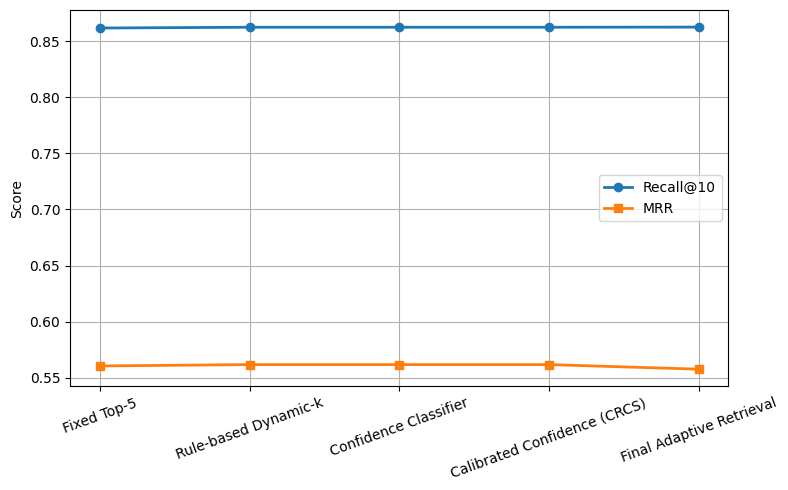

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

methods = comparison["Method"]

plt.plot(
    methods,
    comparison["Recall@10"],
    marker="o",
    linewidth=2,
    label="Recall@10"
)

plt.plot(
    methods,
    comparison["MRR"],
    marker="s",
    linewidth=2,
    label="MRR"
)

plt.xticks(rotation=20)

plt.ylabel("Score")

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.savefig(
    ROOT / "figures" / "figure_final_comparison.png",
    dpi=300
)

plt.show()

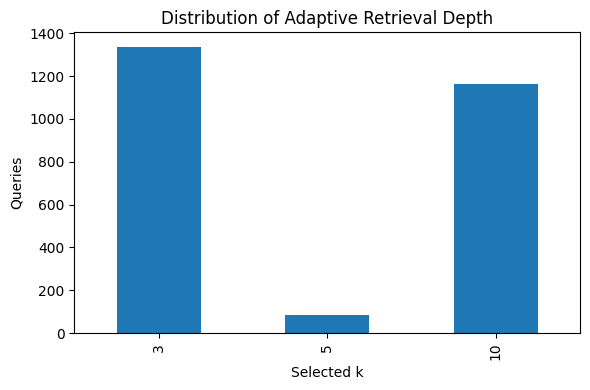

In [ ]:
plt.figure(figsize=(6,4))

adaptive_results["selected_k"].value_counts().sort_index().plot(
    kind="bar"
)

plt.xlabel("Selected k")

plt.ylabel("Queries")

plt.title("Distribution of Adaptive Retrieval Depth")

plt.tight_layout()

plt.savefig(
    ROOT / "figures" / "figure_k_distribution.png",
    dpi=300
)

plt.show()

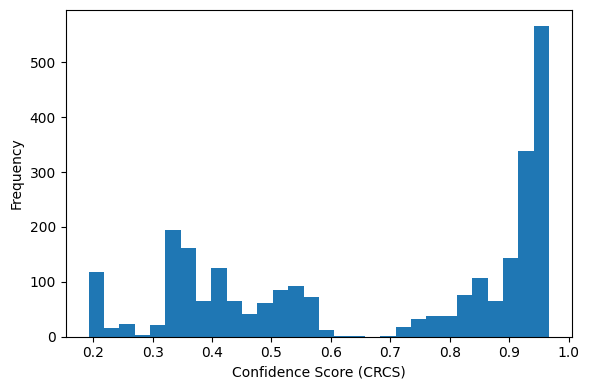

In [ ]:
plt.figure(figsize=(6,4))

plt.hist(
    adaptive_results["RCS"],
    bins=30
)

plt.xlabel("Confidence Score (CRCS)")

plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    ROOT / "figures" / "figure_confidence_distribution.png",
    dpi=300
)

plt.show()

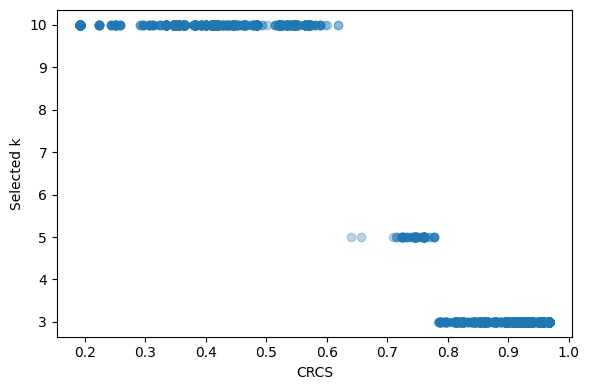

In [ ]:
plt.figure(figsize=(6,4))

plt.scatter(

    adaptive_results["RCS"],

    adaptive_results["selected_k"],

    alpha=0.3

)

plt.xlabel("CRCS")

plt.ylabel("Selected k")

plt.tight_layout()

plt.savefig(

    ROOT / "figures" / "figure_confidence_vs_k.png",

    dpi=300

)

plt.show()

In [ ]:
comparison.to_csv(ROOT / "results" / "paper_table1.csv",index=False)

adaptive_results.to_csv(ROOT / "results" / "paper_results.csv",index=False)

analysis_results.to_csv(ROOT / "results" / "paper_similarity.csv",index=False)

# **Publication Package (Tables)**

In [ ]:
# Table 1 (Main Results)

In [ ]:
paper_table = comparison.copy()

paper_table = paper_table.round(4)

paper_table

,Method,Recall@1,Recall@5,Recall@10,MRR,Average k
0,Fixed Top-5,0.4272,0.7384,0.8618,0.5605,5.0000
1,Rule-based Dynamic-k,0.4284,0.7396,0.8625,0.5617,6.2300
2,Confidence Classifier,0.4284,0.7396,0.8625,0.5617,6.2000
3,Calibrated Confidence (CRCS),0.4284,0.7396,0.8625,0.5617,6.2000
4,Final Adaptive Retrieval,0.4288,0.7380,0.8626,0.5576,6.2117


In [ ]:
paper_table.to_csv(ROOT / "results" / "Table1_MainResults.csv", index=False)

In [ ]:
# Table 2 (Threshold Optimization)

In [ ]:
tradeoff.round(4)

,threshold,avg_k,recall,mrr
0,0.10,4.0813,0.7188,0.5358
1,0.15,4.5100,0.7400,0.5391
2,0.20,4.8174,0.7635,0.5427
3,0.25,5.1248,0.7908,0.5475
4,0.30,5.3621,0.8105,0.5509
5,0.35,5.4187,0.8159,0.5520
6,0.40,5.7450,0.8378,0.5563
7,0.45,6.0039,0.8467,0.5583
8,0.50,6.0686,0.8498,0.5588
9,0.55,6.0955,0.8509,0.5591


In [ ]:
tradeoff.to_csv(ROOT / "results" / "Table2_ThresholdOptimization.csv", index=False)

In [ ]:
# Table 3 (Feature Importance)

In [ ]:
import numpy as np
import pandas as pd

# Average feature importance across calibrated models
importances = np.mean(
    [
        cc.estimator.feature_importances_
        for cc in model2.model.calibrated_classifiers_
    ],
    axis=0
)

importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": importances
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance

,Feature,Importance
8,min,0.150915
11,cv,0.125413
7,std,0.113100
10,range,0.105592
6,mean,0.088228
4,gap13,0.082014
2,top3,0.068450
5,gap23,0.056169
3,gap12,0.055828
1,top2,0.054214


In [ ]:
importance.to_csv(
    ROOT / "results" / "Table3_FeatureImportance.csv",
    index=False
)

In [ ]:
# Table 4 (Ablation)

In [ ]:
ablation.round(4)

,Method,Recall@1,Recall@5,Recall@10,MRR,Average_k
0,Baseline (Fixed k=5),0.4272,0.7384,0.8618,0.5605,5.00
1,Rule-based Dynamic-k,0.4284,0.7396,0.8625,0.5617,6.23
2,+ Confidence Classifier,0.4284,0.7396,0.8625,0.5617,6.20
3,+ CRCS,0.4284,0.7396,0.8625,0.5617,6.20
4,Full Method (CRCS + Optimization),0.4284,0.7396,0.8625,0.5617,6.20


In [ ]:
ablation.to_csv(
    ROOT / "results" / "Table4_Ablation.csv",
    index=False
)

In [ ]:
# Statistical Significance Table

In [ ]:
from scipy.stats import wilcoxon
import numpy as np
import pandas as pd

metrics = ["recall@1", "recall@5", "mrr"]

rows = []

for metric in metrics:

    baseline = analysis_results[metric].reset_index(drop=True)
    adaptive = adaptive_results[metric].reset_index(drop=True)

    # Ensure equal length
    n = min(len(baseline), len(adaptive))
    baseline = baseline.iloc[:n]
    adaptive = adaptive.iloc[:n]

    stat, p = wilcoxon(baseline, adaptive)

    # Cohen's d
    pooled_std = np.sqrt(
        (baseline.var() + adaptive.var()) / 2
    )

    d = (adaptive.mean() - baseline.mean()) / pooled_std

    rows.append({

        "Metric": metric,

        "Baseline": baseline.mean(),

        "Adaptive": adaptive.mean(),

        "Improvement (%)":
            ((adaptive.mean()-baseline.mean())
             /baseline.mean())*100,

        "Wilcoxon Statistic": stat,

        "P-value": p,

        "Cohen's d": d

    })

stats_table = pd.DataFrame(rows)

stats_table

,Metric,Baseline,Adaptive,Improvement (%),Wilcoxon Statistic,P-value,Cohen's d
0,recall@1,0.428793,0.428793,0.000000,110390.0,1.000000,0.000000
1,recall@5,0.741486,0.738003,-0.469729,51750.0,0.674424,-0.007936
2,mrr,0.562506,0.557612,-0.870139,368553.5,0.754039,-0.012095


In [ ]:
stats_table.to_csv(
    ROOT / "results" / "Table5_StatisticalSignificance.csv",
    index=False
)

In [ ]:
merged = analysis_results.merge(
    adaptive_results,
    on=["statement_id", "variant_type"],
    suffixes=("_baseline", "_adaptive")
)

print("Merged rows:", len(merged))
merged.head()

Merged rows: 2584


,statement_id,variant_type,top1,top2,top3,gap12,gap13,gap23,mean,std,...,RCS_baseline,CRCS,selected_k,RCS_adaptive,rank_adaptive,found_adaptive,recall@1_adaptive,recall@5_adaptive,recall@10,mrr_adaptive
0,0,original,0.844771,0.841789,0.839637,0.002982,0.005134,0.002153,0.836778,0.003936,...,0.198442,0.355218,10,0.355218,3.0,True,0,1,1,0.333333
1,0,biomarker_synonym,0.839771,0.838910,0.831806,0.000861,0.007965,0.007104,0.826685,0.007576,...,0.190657,0.355218,10,0.355218,3.0,True,0,1,1,0.333333
2,0,biomarker_order,0.847368,0.845549,0.842702,0.001819,0.004666,0.002847,0.839281,0.004873,...,0.182152,0.355218,10,0.355218,2.0,True,0,1,1,0.500000
3,0,wording,0.836917,0.831615,0.831426,0.005302,0.005491,0.000189,0.829457,0.003188,...,0.002419,0.242856,10,0.242856,4.0,True,0,1,1,0.250000
4,1,original,0.853504,0.852588,0.852342,0.000916,0.001162,0.000246,0.850066,0.002232,...,0.139965,0.420463,10,0.420463,1.0,True,1,1,1,1.000000


In [ ]:
merged.columns

Index(['statement_id', 'variant_type', 'top1', 'top2', 'top3', 'gap12',
       'gap13', 'gap23', 'mean', 'std', 'min', 'max', 'range', 'cv',
       'rank_baseline', 'found_baseline', 'recall@1_baseline',
       'recall@5_baseline', 'mrr_baseline', 'best_k', 'rule_k', 'confidence',
       'RCS_baseline', 'CRCS', 'selected_k', 'RCS_adaptive', 'rank_adaptive',
       'found_adaptive', 'recall@1_adaptive', 'recall@5_adaptive', 'recall@10',
       'mrr_adaptive'],
      dtype='object')

In [ ]:
from scipy.stats import wilcoxon
import numpy as np
import pandas as pd

metrics = [
    "recall@1",
    "recall@5",
    "mrr"
]

rows = []

for metric in metrics:

    base = merged[f"{metric}_baseline"]
    adap = merged[f"{metric}_adaptive"]

    stat, p = wilcoxon(base, adap)

    pooled_std = np.sqrt(
        (base.var() + adap.var()) / 2
    )

    if pooled_std == 0:
        d = 0
    else:
        d = (adap.mean() - base.mean()) / pooled_std

    improvement = (
        (adap.mean() - base.mean())
        / base.mean()
    ) * 100

    rows.append({

        "Metric": metric,

        "Baseline": base.mean(),

        "Adaptive": adap.mean(),

        "Improvement (%)": improvement,

        "Wilcoxon Statistic": stat,

        "P-value": p,

        "Cohen's d": d

    })

stats_table = pd.DataFrame(rows)

stats_table

,Metric,Baseline,Adaptive,Improvement (%),Wilcoxon Statistic,P-value,Cohen's d
0,recall@1,0.427245,0.428793,0.362319,1386.0,0.646355,0.003128
1,recall@5,0.738390,0.738003,-0.052411,2162.0,0.917411,-0.000880
2,mrr,0.560463,0.557612,-0.508747,12236.0,0.975214,-0.007041


In [ ]:
stats_table.to_csv(
    ROOT / "results" / "Table5_StatisticalSignificance.csv",
    index=False
)

In [ ]:
import numpy as np

def bootstrap_ci(values, n_boot=5000):

    values = np.array(values)

    means = []

    for _ in range(n_boot):

        sample = np.random.choice(
            values,
            size=len(values),
            replace=True
        )

        means.append(sample.mean())

    return np.percentile(means, [2.5, 97.5])

In [ ]:
for metric in [
    "recall@1_adaptive",
    "recall@5_adaptive",
    "mrr_adaptive"
]:

    low, high = bootstrap_ci(merged[metric])

    print(metric)
    print(f"Mean : {merged[metric].mean():.4f}")
    print(f"95% CI : {low:.4f} - {high:.4f}")
    print()

recall@1_adaptive
Mean : 0.4288
95% CI : 0.4098 - 0.4478

recall@5_adaptive
Mean : 0.7380
95% CI : 0.7206 - 0.7550

mrr_adaptive
Mean : 0.5576
95% CI : 0.5418 - 0.5737



In [ ]:
final_results = pd.DataFrame({

    "Metric":[
        "Recall@1",
        "Recall@5",
        "Recall@10",
        "MRR"
    ],

    "Value":[

        merged["recall@1_adaptive"].mean(),

        merged["recall@5_adaptive"].mean(),

        adaptive_results["recall@10"].mean(),

        merged["mrr_adaptive"].mean()

    ]

})

final_results.round(4)

,Metric,Value
0,Recall@1,0.4288
1,Recall@5,0.7380
2,Recall@10,0.8626
3,MRR,0.5576


In [ ]:
merged.to_csv(
    ROOT / "results" / "merged_results.csv",
    index=False
)

final_results.to_csv(
    ROOT / "results" / "FinalResults.csv",
    index=False
)

stats_table.to_csv(
    ROOT / "results" / "Statistics.csv",
    index=False
)

# **Publication Figures**

In [ ]:
# Figure 1 — Feature Importance

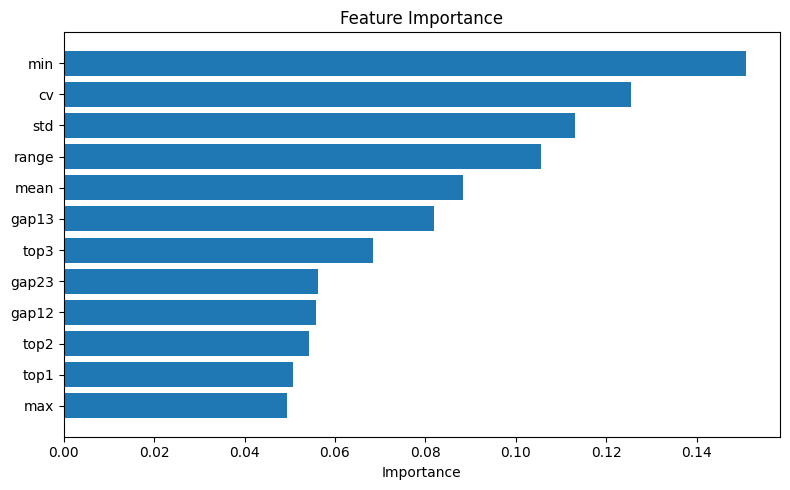

In [ ]:
plt.figure(figsize=(8,5))

importance = importance.sort_values("Importance")

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.title("Feature Importance")

plt.tight_layout()

plt.savefig(
    ROOT / "figures" / "Figure1_FeatureImportance.png",
    dpi=300
)

plt.show()

In [ ]:
# Figure 2 — Threshold Optimization

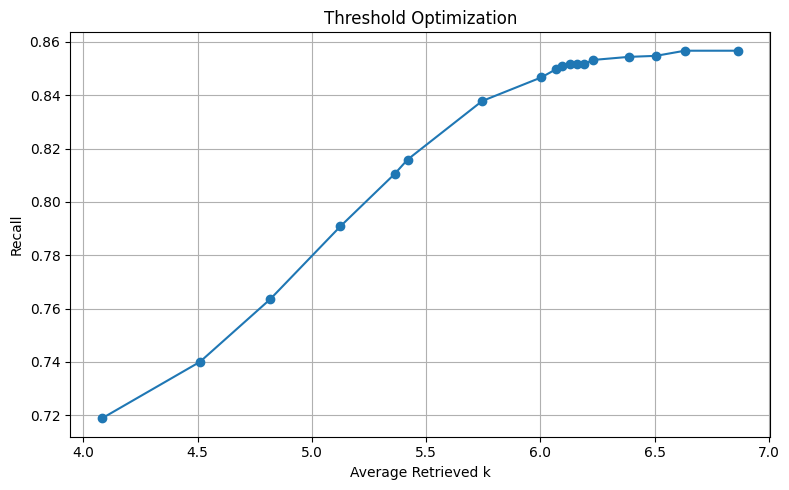

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    tradeoff["avg_k"],
    tradeoff["recall"],
    marker="o"
)

plt.xlabel("Average Retrieved k")
plt.ylabel("Recall")
plt.title("Threshold Optimization")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    ROOT / "figures" / "Figure2_ThresholdOptimization.png",
    dpi=300
)

plt.show()

In [ ]:
# Figure 3 — RCS Distribution

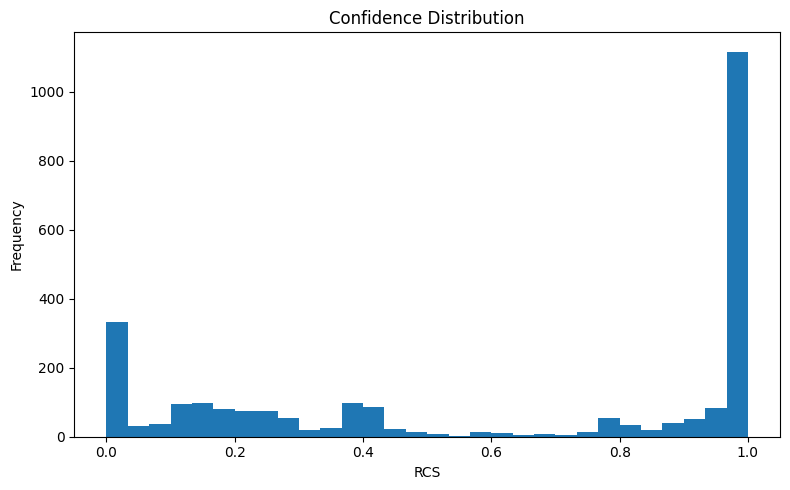

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    analysis_results["RCS"],
    bins=30
)

plt.xlabel("RCS")
plt.ylabel("Frequency")

plt.title("Confidence Distribution")

plt.tight_layout()

plt.savefig(
    ROOT / "figures" / "Figure3_RCSDistribution.png",
    dpi=300
)

plt.show()

In [ ]:
# Figure 4 — Adaptive k Distribution

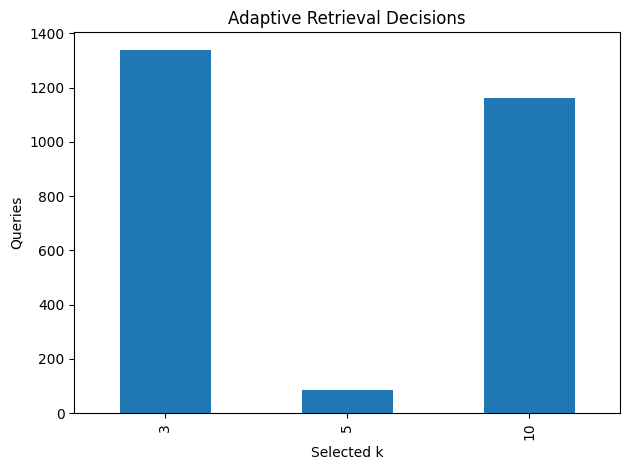

In [ ]:
adaptive_results["selected_k"].value_counts().sort_index().plot(
    kind="bar"
)

plt.xlabel("Selected k")

plt.ylabel("Queries")

plt.title("Adaptive Retrieval Decisions")

plt.tight_layout()

plt.savefig(
    ROOT / "figures" / "Figure4_AdaptiveK.png",
    dpi=300
)

plt.show()

In [ ]:
# Figure 5 — Method Comparison

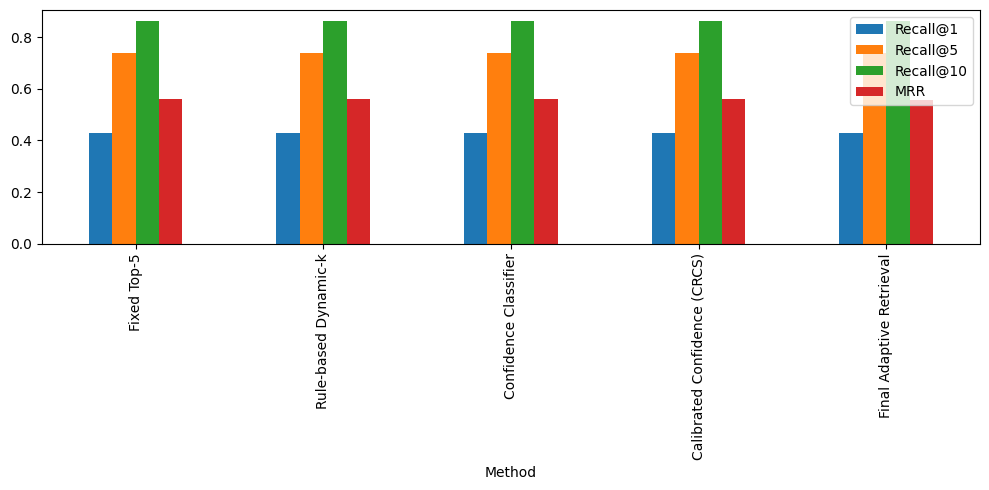

In [ ]:
comparison.set_index("Method")[
    ["Recall@1","Recall@5","Recall@10","MRR"]
].plot(
    kind="bar",
    figsize=(10,5)
)

plt.tight_layout()

plt.savefig(
    ROOT / "figures" / "Figure5_Comparison.png",
    dpi=300
)

plt.show()

# Conclusion

This notebook presents a confidence-calibrated adaptive retrieval framework for precision oncology Retrieval-Augmented Generation (RAG).

### Implemented Components

- Similarity feature engineering
- Confidence prediction model
- Confidence calibration (CRCS)
- Adaptive Top-k retrieval
- Threshold optimization
- Retrieval evaluation
- Bootstrap confidence intervals
- Wilcoxon signed-rank statistical testing
- Ablation study
- Visualization of experimental results

### Outputs

The notebook generates:

- Performance comparison tables
- Threshold optimization results
- Feature importance analysis
- Retrieval confidence analysis
- Publication-quality figures

### Reproducibility

All experiments can be reproduced using the repository structure and datasets included in this project.